# NLG Evaluation Trend Analysis
*Following the plan in `analysis.md`. Run top-to-bottom; re-runnable once
normalisation dicts are finalised in Section 0G.*

## Setup -- Imports and Configuration

In [53]:
import os, re, sys, json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

sys.path.insert(0, os.getcwd())
from helpers import (
    load_results, build_norm_dict, apply_norm, classify_language,
    dual_axis_trend, wilson_ci, save_fig, SIGGEN_VENUES,
)

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
})

RESULTS_CSV   = '../output/results.csv'
RESULTS_JSONL = '../output/results.jsonl'
PAPERS_CSV    = '../papers.csv'

os.makedirs('figures', exist_ok=True)
os.makedirs('tables',  exist_ok=True)
print("Setup complete.")

Setup complete.


---
## Section 0 -- Data Preparation and Sanity Checks

### 0A -- Load and Validate

In [54]:
df_all, raw_records = load_results(RESULTS_JSONL, RESULTS_CSV)
print(f"Total records (all years): {len(df_all):,}")
print(f"\nparse_failed rate: {df_all['parse_failed'].mean()*100:.1f}%")
print(f"\nextraction_method distribution:")
print(df_all['extraction_method'].value_counts().to_string())
print(f"\nYear range: {df_all['year'].min()} - {df_all['year'].max()}")

Total records (all years): 16,587

parse_failed rate: 0.4%

extraction_method distribution:
extraction_method
context_fallback     12901
heading_heuristic     3684

Year range: 1952 - 2026


In [55]:
# -- Pipeline funnel statistics -----------------------------------------------
# Load filtered_papers.csv (only the columns needed for the funnel)
_flt = pd.read_csv(
    '../output/filtered_papers.csv',
    usecols=lambda c: c in {'id', 'passed_filter', 'filter_drop_reason'},
    encoding='utf-8', on_bad_lines='skip', low_memory=False,
)
_flt['passed_filter'] = (
    _flt['passed_filter'].astype(str).str.lower()
    .map({'true': True, 'false': False, '1': True, '0': False})
)

# papers.csv: total anthology papers fetched
_papers_total = pd.read_csv(PAPERS_CSV, usecols=['id'], encoding='utf-8', on_bad_lines='skip').shape[0]

_n_total   = len(_flt)
_n_passed  = int(_flt['passed_filter'].sum())
_drop_counts = (
    _flt[~_flt['passed_filter']]['filter_drop_reason']
    .fillna('unknown')
    .value_counts()
)
_n_llm      = len(df_all)
_n_llm_found = int((df_all['has_human_eval'] | df_all['has_auto_eval'] | df_all['has_llm_judge']).sum())
_n_failed   = int(df_all['parse_failed'].sum())

print("Pipeline funnel")
print("=" * 55)
print(f"  papers.csv (ACL Anthology fetch)      : {_papers_total:>8,}")
print(f"  filtered_papers.csv (filter stage)    : {_n_total:>8,}")
print(f"    passed filter (regex match)          : {_n_passed:>8,}  ({_n_passed/_n_total*100:.1f}%)")
_n_dropped = _n_total - _n_passed
print(f"    dropped                              : {_n_dropped:>8,}  ({_n_dropped/_n_total*100:.1f}%)")
for reason, cnt in _drop_counts.items():
    print(f"      {reason:<34}: {cnt:>7,}  ({cnt/_n_total*100:.1f}%)")
print(f"  results.csv (LLM extraction)           : {_n_llm:>8,}")
print(f"    parse failed                          : {_n_failed:>8,}  ({_n_failed/_n_llm*100:.1f}%)")
print(f"    LLM found evaluation                  : {_n_llm_found:>8,}  ({_n_llm_found/_n_llm*100:.1f}%)")

del _flt  # free memory

Pipeline funnel
  papers.csv (ACL Anthology fetch)      :   85,792
  filtered_papers.csv (filter stage)    :   85,792
    passed filter (regex match)          :   16,587  (19.3%)
    dropped                              :   69,205  (80.7%)
      no_task                           :  61,360  (71.5%)
      no_eval_signal                    :   4,006  (4.7%)
      meta_paper                        :   3,839  (4.5%)
  results.csv (LLM extraction)           :   16,587
    parse failed                          :       61  (0.4%)
    LLM found evaluation                  :   12,157  (73.3%)


In [56]:
# Exclude 2026 (partial year); keep all other years for full trend picture
df     = df_all[df_all['year'] < 2026].copy()
df_2026 = df_all[df_all['year'] == 2026].copy()

print(f"Full dataset (all years < 2026): {len(df):,} papers")
print(f"2026 (partial year, excluded from trend fitting): {len(df_2026):,} papers")
print(f"Year distribution:")
print(df['year'].value_counts().sort_index().to_string())

Full dataset (all years < 2026): 16,523 papers
2026 (partial year, excluded from trend fitting): 64 papers
Year distribution:
year
1952       7
1956       4
1957       2
1960       1
1961       1
1962       5
1963       1
1965       2
1967       3
1969       3
1971       3
1974       1
1975       1
1976       3
1977       1
1978       4
1979       1
1980       7
1981      10
1982       9
1983      18
1984      22
1985      10
1986      24
1987      19
1988      29
1989      22
1990      28
1991      25
1992      36
1993      42
1994      69
1995      38
1996      54
1997      96
1998     108
1999      97
2000      92
2001     139
2002     111
2003     187
2004     197
2005     272
2006     299
2007     320
2008     376
2009     466
2010     569
2011     554
2012     638
2013     573
2014     637
2015     568
2016     728
2017     592
2018     925
2019    1119
2020    1495
2021    1521
2022    1031
2023     743
2024     780
2025     785


In [57]:
# -- Non-English venue exclusion -----------------------------------------------
# Papers from the following venues are predominantly non-English and may not
# have been parsed correctly by the English-prompt LLM extractor.
# French: JEP, RECITAL, TAL, TALN
# Chinese: ROCLING, IJCLCLP, CCL
NON_ENGLISH_VENUES = {
    'jep', 'recital', 'tal', 'taln',          # French NLP venues
    'rocling', 'ijclclp', 'ccl',               # Chinese NLP venues
}

_before = len(df)
df = df[~df['venue'].isin(NON_ENGLISH_VENUES)].copy()
_excluded = _before - len(df)

print(f"Non-English venue exclusion: removed {_excluded:,} papers")
print(f"  Remaining: {len(df):,} papers")
if _excluded:
    # Propagate to df_all mirror (kept for reference only; analyses use df)
    print("  Excluded venue breakdown:")
    print(
        df_all[df_all['venue'].isin(NON_ENGLISH_VENUES)]
        ['venue'].value_counts().to_string()
    )

Non-English venue exclusion: removed 41 papers
  Remaining: 16,482 papers
  Excluded venue breakdown:
venue
ccl        31
rocling     6
ijclclp     4


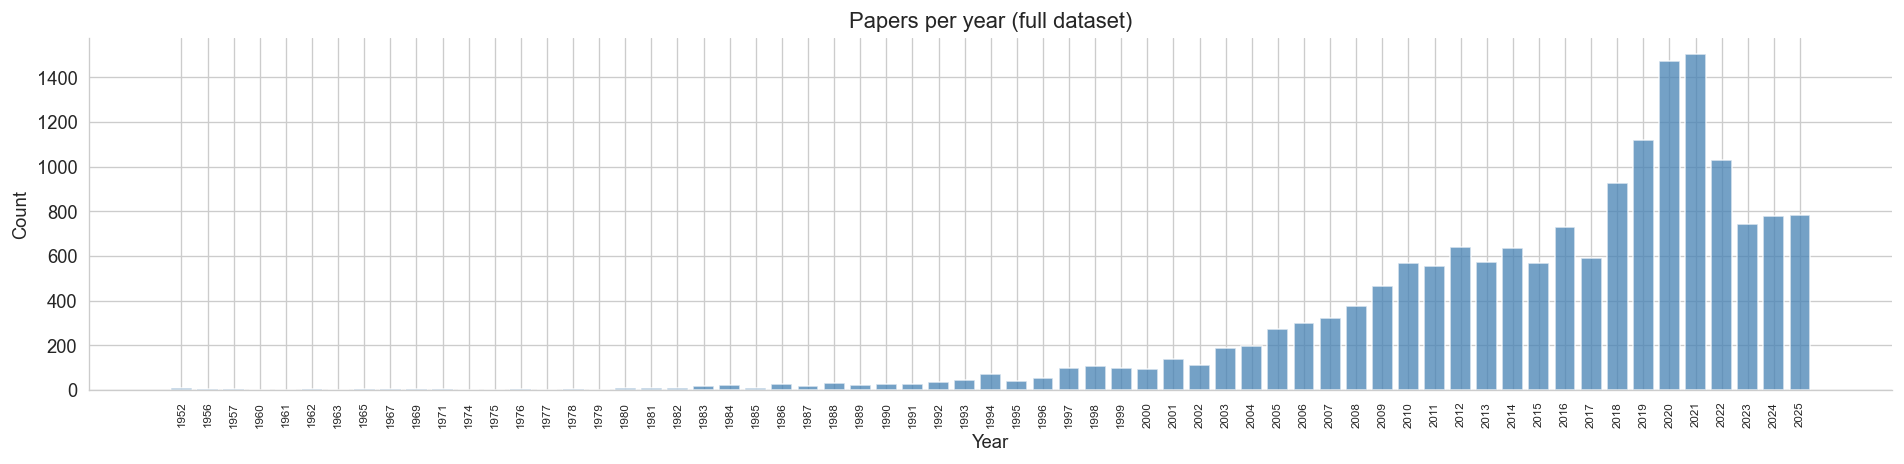

In [58]:
# Year distribution histogram -- show all years with at least 1 paper
fig, ax = plt.subplots(figsize=(16, 4))
yc = df['year'].value_counts().sort_index()
bars = ax.bar(yc.index.astype(str), yc.values, color='steelblue', alpha=0.75)
ax.set_title('Papers per year (full dataset)')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
save_fig(fig, 'fig00_year_distribution')
plt.show()

In [59]:
# Merge abstract from papers.csv (read only needed columns -- the file is large)
papers_meta = pd.read_csv(
    PAPERS_CSV, usecols=['id', 'abstract'],
    encoding='utf-8', on_bad_lines='skip'
)
df = df.merge(
    papers_meta.rename(columns={'id': 'paper_id'}),
    on='paper_id', how='left'
)
print(f"Abstract coverage: {df['abstract'].notna().sum():,} / {len(df):,} "
      f"({df['abstract'].notna().mean()*100:.1f}%)")

Abstract coverage: 16,212 / 16,482 (98.4%)


In [60]:
# Papers where all three LLM-confirmed booleans are False (regex FP, LLM rejected)
df['all_eval_false'] = ~df['has_human_eval'] & ~df['has_auto_eval'] & ~df['has_llm_judge']
n_fp = df['all_eval_false'].sum()
print(f"Papers with all eval types False (regex FP): {n_fp} ({n_fp/len(df)*100:.1f}%)")
print("These are kept in the denominator but excluded from eval-specific analyses.")

Papers with all eval types False (regex FP): 4408 (26.7%)
These are kept in the denominator but excluded from eval-specific analyses.


### 0B -- Flag Meta-Evaluation Papers

In [61]:
META_EVAL_RE = re.compile(
    r'\bmeta[\s-]?evaluat|\bevaluat\w+\s+(metric|evaluation method)|'
    r'\bcorrelation\s+with\s+human\b|\bbenchmark\w*\s+(metric|evaluation)\b|'
    r'\bmetric\s+(comparison|benchmark|analysis)\b',
    re.IGNORECASE,
)
df['is_meta_eval'] = (
    df['title'].str.contains(META_EVAL_RE, na=False)
    | df['abstract'].str.contains(META_EVAL_RE, na=False)
)
n_meta = df['is_meta_eval'].sum()
print(f"Meta-eval papers flagged: {n_meta} ({n_meta/len(df)*100:.1f}%)")
print("\nMeta-eval rate by year (>10% in a stratum warrants a caveat):")
meta_yr = df.groupby('year')['is_meta_eval'].agg(['sum', 'mean'])
meta_yr.columns = ['count', 'rate']
meta_yr['rate_%'] = (meta_yr['rate'] * 100).round(1)
print(meta_yr.to_string())

Meta-eval papers flagged: 798 (4.8%)

Meta-eval rate by year (>10% in a stratum warrants a caveat):
      count      rate  rate_%
year                         
1952      0  0.000000     0.0
1956      0  0.000000     0.0
1957      0  0.000000     0.0
1960      0  0.000000     0.0
1961      0  0.000000     0.0
1962      0  0.000000     0.0
1963      0  0.000000     0.0
1965      0  0.000000     0.0
1967      0  0.000000     0.0
1969      0  0.000000     0.0
1971      0  0.000000     0.0
1974      0  0.000000     0.0
1975      0  0.000000     0.0
1976      0  0.000000     0.0
1977      0  0.000000     0.0
1978      0  0.000000     0.0
1979      0  0.000000     0.0
1980      0  0.000000     0.0
1981      0  0.000000     0.0
1982      0  0.000000     0.0
1983      0  0.000000     0.0
1984      0  0.000000     0.0
1985      0  0.000000     0.0
1986      0  0.000000     0.0
1987      0  0.000000     0.0
1988      0  0.000000     0.0
1989      0  0.000000     0.0
1990      0  0.000000     0.0


### 0C -- Multi-Task Paper Handling

In [62]:
df['task_list']    = df['inferred_tasks'].fillna('').str.split('|')
df['num_tasks']    = df['task_list'].apply(len)
df['is_multi_task'] = df['num_tasks'] > 1

print(f"Multi-task papers: {df['is_multi_task'].sum()} ({df['is_multi_task'].mean()*100:.1f}%)")
print(f"\nnum_tasks distribution:")
print(df['num_tasks'].value_counts().sort_index().to_string())

print("\nContingency: multi_task x has_human_eval")
print(pd.crosstab(df['is_multi_task'], df['has_human_eval'],
                  rownames=['multi_task'], colnames=['has_human_eval'], margins=True))
print("\nContingency: multi_task x has_auto_eval")
print(pd.crosstab(df['is_multi_task'], df['has_auto_eval'],
                  rownames=['multi_task'], colnames=['has_auto_eval'], margins=True))

Multi-task papers: 1522 (9.2%)

num_tasks distribution:
num_tasks
1    14960
2     1330
3      162
4       28
5        2

Contingency: multi_task x has_human_eval
has_human_eval  False  True    All
multi_task                        
False           11439  3521  14960
True              954   568   1522
All             12393  4089  16482

Contingency: multi_task x has_auto_eval
has_auto_eval  False   True    All
multi_task                        
False           5694   9266  14960
True             537    985   1522
All             6231  10251  16482


In [63]:
# Exploded DataFrames -- used throughout all task-stratified analyses
df_tasks = df.explode('task_list').rename(columns={'task_list': 'task'})
df_tasks = df_tasks[df_tasks['task'].str.strip() != ''].copy()

df_single = (
    df[~df['is_multi_task']]
    .explode('task_list')
    .rename(columns={'task_list': 'task'})
)
df_single = df_single[df_single['task'].str.strip() != ''].copy()

print(f"df_tasks  (all papers exploded):    {len(df_tasks):,} rows")
print(f"df_single (single-task exploded):   {len(df_single):,} rows")
print("\nTop 12 tasks (df_single):")
print(df_single['task'].value_counts().head(12).to_string())

df_tasks  (all papers exploded):    18,228 rows
df_single (single-task exploded):   14,960 rows

Top 12 tasks (df_single):
task
machine_translation    9354
summarization          1659
dialogue               1223
general_nlg            1019
paraphrase              621
question_generation     261
captioning              216
data_to_text            166
simplification          148
code_generation         135
style_transfer           97
story_generation         61


### 0D -- Language Categorisation

Language group distribution:
lang_group
unknown             10832
multilingual         4285
english_only          930
non_english_mono      435


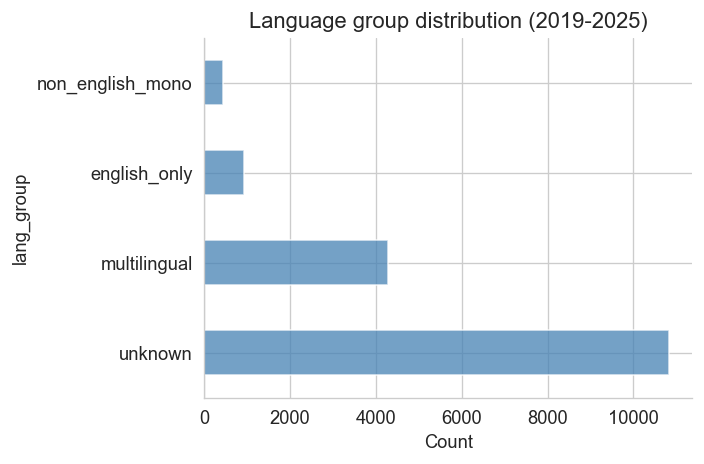

In [64]:
df['lang_group']       = df.apply(classify_language, axis=1)
df_tasks['lang_group'] = df_tasks.apply(classify_language, axis=1)
df_single['lang_group'] = df_single.apply(classify_language, axis=1)

print("Language group distribution:")
print(df['lang_group'].value_counts().to_string())

fig, ax = plt.subplots(figsize=(6, 4))
df['lang_group'].value_counts().plot(kind='barh', ax=ax, color='steelblue', alpha=0.75)
ax.set_title('Language group distribution (2019-2025)')
ax.set_xlabel('Count')
plt.tight_layout()
save_fig(fig, 'fig00_lang_group')
plt.show()

### 0E/F -- Year Handling & Venue Grouping

2026 is marked incomplete and excluded from trend fitting (use as dashed line). Venue groups defined for stratified analyses.

Venue group distribution:
venue_group
other         8184
core_nlp      7515
generation     435
journals       348

Generation venues: ['aiwolfdial', 'ccnlg', 'dt4tp', 'enlg', 'evalnlgeval', 'gem', 'inlg', 'intellang', 'msr', 'nl4xai', 'siggen', 'webnlg']


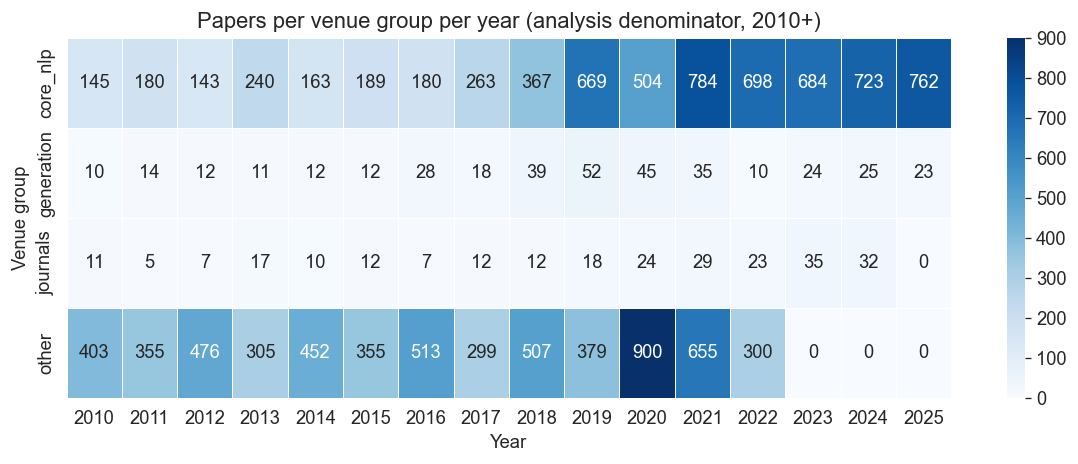

In [65]:
VENUE_GROUPS = {
    'generation': sorted(SIGGEN_VENUES),   # inlg, enlg, gem, webnlg, etc.
    'core_nlp':   ['acl', 'emnlp', 'naacl', 'eacl', 'aacl', 'ijcnlp'],
    'journals':   ['tacl', 'cl'],
}

def get_venue_group(venue):
    v = str(venue).lower().strip()
    for group, members in VENUE_GROUPS.items():
        if v in members:
            return group
    return 'other'

for frame in (df, df_tasks, df_single):
    frame['venue_group'] = frame['venue'].apply(get_venue_group)

print('Venue group distribution:')
print(df['venue_group'].value_counts().to_string())
print('\nGeneration venues:', sorted(VENUE_GROUPS['generation']))

# Denominator heatmap restricted to 2010+ for readability
denom = df[df['year'] >= 2010].groupby(['venue_group', 'year']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(denom, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Papers per venue group per year (analysis denominator, 2010+)')
ax.set_xlabel('Year')
ax.set_ylabel('Venue group')
plt.tight_layout()
save_fig(fig, 'fig00_denominator_heatmap')
plt.show()

### 0G -- Build Normalisation Dictionaries

**Review the frequency tables below before modifying the dicts.  All entries that cannot be confidently mapped go into "other".**

In [66]:
# -- Human evaluation criteria ---------------------------------------------
criteria_freq, _ = build_norm_dict(df['human_eval_criteria'])
print(f"Unique raw criteria values: {len(criteria_freq)}")
print("\nTop 60 criteria by frequency:")
print(criteria_freq.head(60).to_string(index=False))

Unique raw criteria values: 823

Top 60 criteria by frequency:
                value  count
              fluency    730
             adequacy    565
            relevance    523
         faithfulness    356
       grammaticality    306
            coherence    294
      other — specify    245
      informativeness    229
          naturalness    192
              quality    170
             accuracy    155
          correctness     96
          readability     68
            diversity     36
    understandability     35
          consistency     26
           simplicity     24
 meaning_preservation     23
      appropriateness     23
             coverage     21
  semantic_similarity     19
  translation_quality     19
             fidelity     18
 content_preservation     18
                other     17
           usefulness     17
      overall_quality     17
            precision     16
         engagingness     16
         completeness     15
           factuality     15
    compr

In [67]:
CRITERIA_NORM = {
    # Output quality
    'fluency': 'fluency',              'flu': 'fluency',
    'grammaticality': 'grammaticality', 'grammatical': 'grammaticality',
    'naturalness': 'naturalness',       'natural': 'naturalness',
    'readability': 'readability',       'readble': 'readability',
    # Semantic fidelity
    'adequacy': 'adequacy',            'ade': 'adequacy',
    'faithfulness': 'faithfulness',    'faithful': 'faithfulness',
    'factuality': 'faithfulness',      'fidelity': 'faithfulness',
    'factual_consistency': 'faithfulness',
    'factual consistency': 'faithfulness',
    'content_preservation': 'faithfulness',
    'semantic_similarity': 'faithfulness',
    'accuracy': 'accuracy',            'accurate': 'accuracy',
    'correctness': 'accuracy',
    'consistency': 'consistency',      'consistent': 'consistency',
    # Discourse
    'coherence': 'coherence',          'coherent': 'coherence',
    'cohesion': 'cohesion',
    'structure': 'structure',
    # Task-specific
    'relevance': 'relevance',          'relevant': 'relevance',
    'informativeness': 'informativeness', 'informativity': 'informativeness',
    'informative': 'informativeness',  'coverage': 'coverage',
    'engagingness': 'engagingness',    'engaging': 'engagingness',
    'engagement': 'engagingness',
    'simplicity': 'simplicity',
    'understandability': 'understandability',
    'understandable': 'understandability',
    'comprehensibility': 'understandability',
    'intelligibility': 'understandability',
    'overall_quality': 'overall_quality', 'overall': 'overall_quality',
    'quality': 'overall_quality',
    'translation_quality': 'overall_quality',
    'meaning_preservation': 'meaning_preservation',
    'meaning preservation': 'meaning_preservation',
    'style': 'style',                  'terminology': 'terminology',
    'conciseness': 'conciseness',      'diversity': 'diversity',
    'appropriateness': 'appropriateness',
    'usefulness': 'usefulness',        'helpfulness': 'usefulness',
    'preference': 'preference',
    'other - specify': 'other',   'other': 'other',
}

for frame in (df, df_tasks, df_single):
    frame['criteria_norm'] = apply_norm(frame['human_eval_criteria'], CRITERIA_NORM)

crit_check, _ = build_norm_dict(df['criteria_norm'])
print("Normalised criteria (top 25):")
print(crit_check.head(25).to_string(index=False))

Normalised criteria (top 25):
               value  count
               other   1109
             fluency    730
            adequacy    565
           relevance    525
        faithfulness    430
      grammaticality    307
           coherence    296
            accuracy    251
     informativeness    243
     overall_quality    210
         naturalness    192
         readability     68
   understandability     64
           diversity     36
        engagingness     30
          usefulness     27
         consistency     26
meaning_preservation     25
          simplicity     24
     appropriateness     23
            coverage     21
         conciseness     12
          preference     11
               style     11
         terminology      3


In [68]:
# -- Auto metrics ----------------------------------------------------------
metrics_freq, _ = build_norm_dict(df['auto_metrics'])
print(f"Unique raw metric values: {len(metrics_freq)}")
print("\nTop 80 metrics by frequency:")
print(metrics_freq.head(80).to_string(index=False))

Unique raw metric values: 4399

Top 80 metrics by frequency:
                     value  count
                      bleu   4483
                     rouge    570
                    meteor    547
                  accuracy    489
                       ter    395
                   rouge-l    327
                      nist    277
                 precision    267
                   rouge-1    266
                perplexity    262
                   rouge-2    260
                    recall    260
                 bertscore    200
                    bleu-4    151
                        f1    140
                       wer    134
                     cider    134
                  f1 score    107
                      chrf    103
                     comet     87
                 sacrebleu     81
                 f-measure     78
                     ribes     77
                  f1-score     76
                   f-score     70
                  f1_score     63
     word error rate 

In [69]:
METRIC_NORM = {
    # BLEU family
    'bleu': 'BLEU',         'bleu-1': 'BLEU',   'bleu-2': 'BLEU',
    'bleu-3': 'BLEU',       'bleu-4': 'BLEU',   'bleu1': 'BLEU',
    'bleu2': 'BLEU',        'bleu3': 'BLEU',    'bleu4': 'BLEU',
    'sacrebleu': 'BLEU',    'bleu score': 'BLEU', 'case-sensitive bleu': 'BLEU',
    # ROUGE family
    'rouge': 'ROUGE',       'rouge-1': 'ROUGE',  'rouge-2': 'ROUGE',
    'rouge-l': 'ROUGE',     'rouge-w': 'ROUGE',  'rouge1': 'ROUGE',
    'rouge2': 'ROUGE',      'rougel': 'ROUGE',   'rouge_1': 'ROUGE',
    'rouge_2': 'ROUGE',     'rouge_l': 'ROUGE',  'rouge-su4': 'ROUGE',
    'r-l': 'ROUGE',         'r-2': 'ROUGE',
    # chrF
    'chrf': 'chrF',         'chrf++': 'chrF',   'chrf+++': 'chrF',
    'chrf+': 'chrF',        'chr-f': 'chrF',
    # TER / WER
    'ter': 'TER',           'hter': 'TER',
    'wer': 'WER',           'word error rate (wer)': 'WER',
    'word error rate': 'WER', 'word_error_rate': 'WER',
    # Neural metrics
    'bertscore': 'BERTScore', 'bert_score': 'BERTScore', 'bert score': 'BERTScore',
    'bleurt': 'BLEURT',
    'comet': 'COMET',       'comet-da': 'COMET',  'comet-qe': 'COMET',
    'comet22': 'COMET',     'comet-22': 'COMET',
    'moverscore': 'MoverScore', 'mover score': 'MoverScore',
    'bartscore': 'BARTScore', 'bart_score': 'BARTScore', 'bart score': 'BARTScore',
    'unieval': 'UniEval',
    # Other lexical
    'meteor': 'METEOR',     'me-teor': 'METEOR',
    'nist': 'NIST',         'cider': 'CIDEr',    'spice': 'SPICE',
    'parent': 'PARENT',     'sari': 'SARI',
    'ribes': 'RIBES',       'gtm': 'GTM',        'aer': 'AER',  'per': 'PER',
    'perplexity': 'Perplexity', 'ppl': 'Perplexity',
    # Task-specific / classification
    'f1': 'F1',             'f-1': 'F1',         'f1 score': 'F1',
    'f1_score': 'F1',       'f-score': 'F1',     'f1-score': 'F1', 'f-measure': 'F1',
    'exact match': 'Exact Match', 'exact_match': 'Exact Match',
    'exact match (em)': 'Exact Match',
    'accuracy': 'Accuracy', 'acc': 'Accuracy',
    'precision': 'Precision', 'recall': 'Recall',
    'ser': 'SER',
    'distinct-1': 'Distinct', 'distinct-2': 'Distinct', 'distinct': 'Distinct',
    'self-bleu': 'Self-BLEU',
    'mrr': 'MRR',           'coverage': 'Coverage',
    'cosine_similarity': 'Cosine Similarity',
    'pearson correlation': 'Pearson r',
    'not specified': 'other',
}

for frame in (df, df_tasks, df_single):
    frame['metrics_norm'] = apply_norm(frame['auto_metrics'], METRIC_NORM)
    frame['num_metrics'] = (
        frame['metrics_norm']
        .str.split('|')
        .apply(lambda x: len([m for m in x if m.strip() and m != 'other']))
    )

metrics_check, _ = build_norm_dict(df['metrics_norm'])
print("Normalised metrics (top 30):")
print(metrics_check.head(30).to_string(index=False))

Normalised metrics (top 30):
      value  count
       bleu   4774
      other   3444
      rouge   1103
     meteor    570
         f1    535
   accuracy    516
        ter    448
 perplexity    303
       nist    277
  precision    267
     recall    260
        wer    255
  bertscore    203
       chrf    141
      cider    134
      comet     91
      ribes     77
     bleurt     61
        per     56
       sari     51
exact match     48
   distinct     44
      spice     32
  self-bleu     31
        mrr     27
   coverage     24
        aer     22
  bartscore     22
  pearson r     21
        gtm     20


In [70]:
# -- Human eval methods ----------------------------------------------------
methods_freq, _ = build_norm_dict(df['human_eval_methods'])
print("Human eval methods (all values):")
print(methods_freq.to_string(index=False))

METHODS_NORM = {
    'likert_scale': 'likert_scale',    'likert': 'likert_scale',
    'likert scale': 'likert_scale',    'rating': 'likert_scale',
    'ranking': 'ranking',              'rank': 'ranking',
    'pairwise_comparison': 'pairwise_comparison',
    'pairwise': 'pairwise_comparison', 'pairwise comparison': 'pairwise_comparison',
    'error_span_annotation': 'error_span_annotation',
    'error annotation': 'error_span_annotation',
    'error span annotation': 'error_span_annotation',
    'binary_classification': 'binary_classification',
    'binary': 'binary_classification', 'binary classification': 'binary_classification',
    'free_text': 'free_text',          'free text': 'free_text',
    'post_editing': 'post_editing',    'post editing': 'post_editing',
    'direct_assessment': 'direct_assessment', 'da': 'direct_assessment',
    'direct assessment': 'direct_assessment',
    'mqm': 'MQM',
    'best_worst_scaling': 'best_worst_scaling',
    'crowdsourced': 'crowdsourced',    'crowdsourcing': 'crowdsourced',
    'other': 'other',
}

MT_METHODS_NORM = {
    'da': 'direct_assessment', 'direct_assessment': 'direct_assessment',
    'direct assessment': 'direct_assessment',
    'mqm': 'MQM',
    'esa': 'ESA',              'expert-sourced assessment': 'ESA',
    'psqm': 'pSQM',            'sqm': 'SQM',
    'hter': 'HTER',
    'post_editing': 'post_editing', 'post editing': 'post_editing',
    'other': 'other',
}

for frame in (df, df_tasks, df_single):
    frame['methods_norm']    = apply_norm(frame['human_eval_methods'], METHODS_NORM)
    frame['mt_methods_norm'] = apply_norm(frame['human_eval_mt_methods'], MT_METHODS_NORM)

print("\nMT-specific methods after normalisation:")
mt_check, _ = build_norm_dict(df['mt_methods_norm'])
print(mt_check.to_string(index=False))

Human eval methods (all values):
                                value  count
                binary_classification   1286
                              ranking    753
                                other    710
                         likert_scale    580
                  pairwise_comparison    352
                            free_text    200
                error_span_annotation    174
                         post_editing     98
                    direct_assessment     50
                                  mqm     21
                   best_worst_scaling     18
                         crowdsourced     12
                               survey      5
                                  sqm      3
                                  mos      3
                               rating      3
                      manual_analysis      3
                             adequacy      2
                           annotation      2
                                 hter      2
    correlation_with_h

### 0H -- LLM Judge Type Classification

Distinguish instruction-following LLMs used as evaluators (GPT-4, Claude, etc.) from ML models used for automated scoring without instruction prompting (GPT-2 perplexity, CLIP, RoBERTa discriminators, etc.).

In [71]:
_INSTRUCTION_RE = re.compile(
    r'gpt-4|gpt4|gpt-3[.]5|gpt3[.]5|chatgpt|text-davinci-00[23]'
    r'|claude-?[1-9]|claude [1-9]|gemini|palm-?2|bard|command-?r'
    r'|llama-?[23]|llama [23]|vicuna|alpaca|mistral|falcon|instructgpt',
    re.IGNORECASE,
)
_ML_JUDGE_RE = re.compile(
    r'\bgpt-?2\b|discriminator|adversarial.*classif|\bclip\b'
    r'|roberta.*classif|bert.*classif|infersent|reward[- ]model'
    r'|perplexit|nli[- ]model|trained[- ]classif',
    re.IGNORECASE,
)

def classify_llm_judge_type(model_str):
    if pd.isna(model_str) or not str(model_str).strip():
        return 'unknown'
    s = str(model_str)
    if _INSTRUCTION_RE.search(s):
        return 'instruction_llm'
    if _ML_JUDGE_RE.search(s):
        return 'ml_evaluator'
    return 'unknown'

df['llm_judge_type']     = df['llm_judge_model'].apply(classify_llm_judge_type)
df['has_true_llm_judge'] = df['has_llm_judge'] & (df['llm_judge_type'] == 'instruction_llm')
df['has_ml_judge']       = df['has_llm_judge'] & (df['llm_judge_type'] == 'ml_evaluator')

for col in ('llm_judge_type', 'has_true_llm_judge', 'has_ml_judge'):
    _map = df.set_index('paper_id')[col]
    df_tasks[col]  = df_tasks['paper_id'].map(_map)
    df_single[col] = df_single['paper_id'].map(_map)

print('LLM judge type (among has_llm_judge=True papers):')
print(df[df['has_llm_judge']]['llm_judge_type'].value_counts().to_string())
print(f'\nTotal has_true_llm_judge : {df["has_true_llm_judge"].sum():,}')
print(f'Total has_ml_judge        : {df["has_ml_judge"].sum():,}')
print('\nSample models per type:')
for t in ('instruction_llm', 'ml_evaluator', 'unknown'):
    samp = df[df['llm_judge_type'] == t]['llm_judge_model'].dropna().value_counts().head(5)
    print(f'  {t}: {list(samp.index)}')


LLM judge type (among has_llm_judge=True papers):
llm_judge_type
instruction_llm    120
unknown            109
ml_evaluator         8

Total has_true_llm_judge : 120
Total has_ml_judge        : 8

Sample models per type:
  instruction_llm: ['GPT-4', 'GPT-4o', 'ChatGPT', 'Gemini', 'GPT-4o-mini']
  ml_evaluator: ['GPT-2', 'purposely-trained classifiers', 'discriminator', 'GPT-2 small', 'CLIP']
  unknown: ['LLM', 'LLMs', 'not specified', 'GPT-eval', 'NoDeeLe']


---
## Section 1 -- RQ1: Prevalence of Human Evaluation

In [72]:
n_he = df['has_human_eval'].sum()
print(f"Papers with human eval: {n_he:,} / {len(df):,} ({n_he/len(df)*100:.1f}%)")
print("\nBy year:")
print(df.groupby('year')['has_human_eval']
      .agg(['sum', 'count', 'mean'])
      .rename(columns={'sum': 'count_he', 'count': 'total', 'mean': 'rate'})
      .to_string())

Papers with human eval: 4,089 / 16,482 (24.8%)

By year:
      count_he  total      rate
year                           
1952         0      7  0.000000
1956         0      4  0.000000
1957         0      2  0.000000
1960         0      1  0.000000
1961         0      1  0.000000
1962         0      5  0.000000
1963         0      1  0.000000
1965         0      2  0.000000
1967         1      3  0.333333
1969         0      3  0.000000
1971         0      3  0.000000
1974         0      1  0.000000
1975         0      1  0.000000
1976         0      3  0.000000
1977         0      1  0.000000
1978         0      4  0.000000
1979         0      1  0.000000
1980         0      7  0.000000
1981         1     10  0.100000
1982         0      9  0.000000
1983         0     18  0.000000
1984         1     22  0.045455
1985         1     10  0.100000
1986         2     24  0.083333
1987         0     19  0.000000
1988         0     29  0.000000
1989         1     22  0.045455
1990         0 

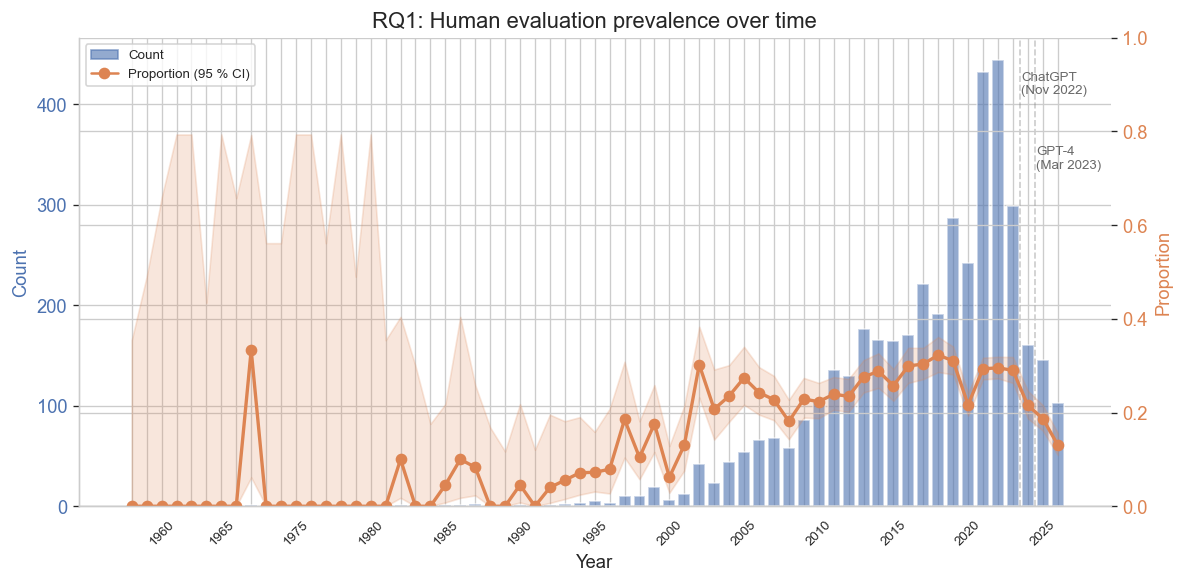

In [73]:
# 1.1 Overall time trend
fig, ax = plt.subplots(figsize=(10, 5))
_, ax_bar, ax_line = dual_axis_trend(
    df, 'year', 'has_human_eval',
    'RQ1: Human evaluation prevalence over time', ax=ax,
)

years_list = sorted(df['year'].unique())
for yr, label, ypos in [(2022, 'ChatGPT\n(Nov 2022)', 0.88), (2023, 'GPT-4\n(Mar 2023)', 0.72)]:
    if yr in years_list:
        idx = years_list.index(yr)
        ax_bar.axvline(idx + 0.5, color='grey', linestyle='--', alpha=0.4, linewidth=1)
        ax_line.annotate(label, xy=(idx + 0.55, ypos),
                         xycoords=('data', 'axes fraction'),
                         fontsize=8, color='dimgray', ha='left')

plt.tight_layout()
save_fig(fig, 'rq1_human_eval_trend')
plt.show()

In [74]:
# 1.2 Logistic regression: has_human_eval ~ year
try:
    import statsmodels.formula.api as smf
    _df_reg = df.assign(has_human_eval=df['has_human_eval'].astype(int))
    result = smf.logit('has_human_eval ~ year', data=_df_reg).fit(disp=False)
    coef = result.params['year']
    print(f"Logistic regression: has_human_eval ~ year")
    print(f"  Coefficient: {coef:.4f}  |  Odds ratio per year: {np.exp(coef):.4f}  |  p={result.pvalues['year']:.4f}")
except Exception as e:
    print(f"statsmodels unavailable ({e}); using scipy fallback")
    # Simple annual proportions + Pearson correlation as proxy
    yr_rates = df.groupby('year')['has_human_eval'].mean()
    r, p = stats.pearsonr(yr_rates.index, yr_rates.values)
    print(f"  Pearson r(year, prop_he) = {r:.4f}, p = {p:.4f}")

# Chi-squared: pre-2023 vs. post-2023
ct = pd.crosstab(df['year'] >= 2023, df['has_human_eval'])
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f"\nChi-squared (pre-2023 vs. post-2023): chi2={chi2:.2f}, p={p:.4f}")

statsmodels unavailable (No module named 'statsmodels'); using scipy fallback
  Pearson r(year, prop_he) = 0.7911, p = 0.0000

Chi-squared (pre-2023 vs. post-2023): chi2=71.84, p=0.0000


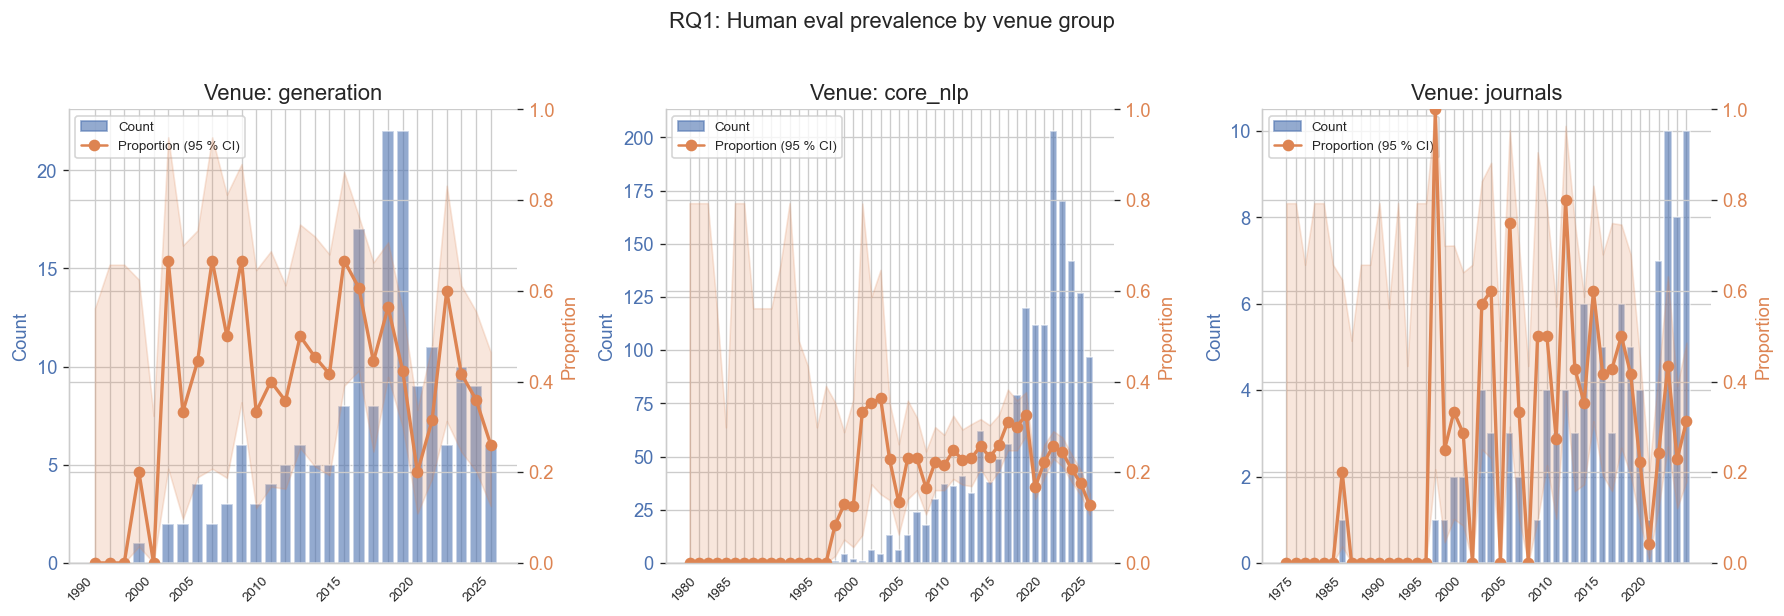


Mean % human eval by venue group (full period):
             with_human_eval  total      rate  rate_%
venue_group                                          
core_nlp                1636   7515  0.217698    21.8
generation               176    435  0.404598    40.5
journals                 105    348  0.301724    30.2
other                   2172   8184  0.265396    26.5


In [75]:
# 1.3 By venue group -- small multiples
fig, axes = plt.subplots(1, len(VENUE_GROUPS), figsize=(15, 5), sharey=False)
for ax, vg in zip(axes, VENUE_GROUPS):
    sub = df[df['venue_group'] == vg]
    if len(sub) == 0:
        ax.set_title(f'{vg} (no data)')
        continue
    dual_axis_trend(sub, 'year', 'has_human_eval', f'Venue: {vg}', ax=ax)
    ax.set_xlabel('')
plt.suptitle('RQ1: Human eval prevalence by venue group', y=1.02)
plt.tight_layout()
save_fig(fig, 'rq1_by_venue')
plt.show()

tbl_venue = df.groupby('venue_group')['has_human_eval'].agg(['sum', 'count', 'mean'])
tbl_venue.columns = ['with_human_eval', 'total', 'rate']
tbl_venue['rate_%'] = (tbl_venue['rate'] * 100).round(1)
print("\nMean % human eval by venue group (full period):")
print(tbl_venue.to_string())

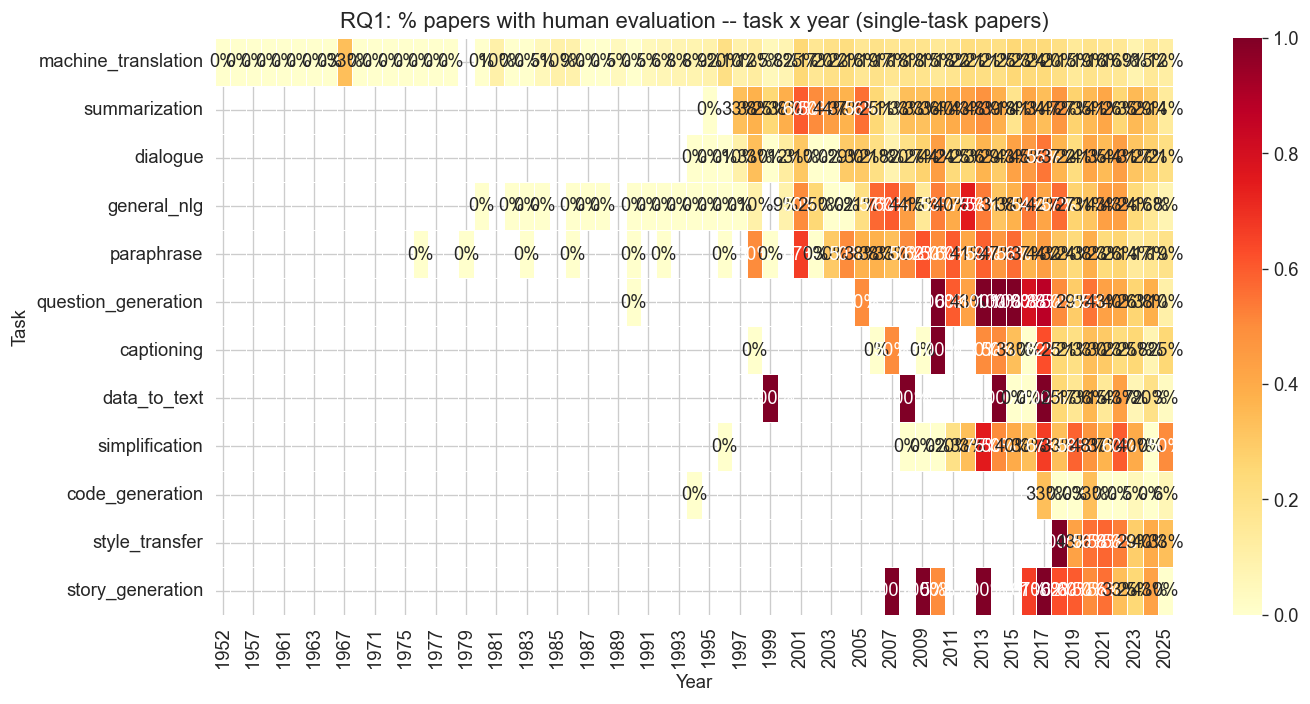

In [76]:
# 1.4 Task x year heatmap (df_single)
ptask = (
    df_single.groupby(['task', 'year'])['has_human_eval']
    .agg(['sum', 'count'])
    .reset_index()
    .assign(rate=lambda x: x['sum'] / x['count'])
    .pivot(index='task', columns='year', values='rate')
)
top_tasks_12 = df_single['task'].value_counts().head(12).index
ptask = ptask.reindex(top_tasks_12).dropna(how='all')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ptask, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('RQ1: % papers with human evaluation -- task x year (single-task papers)')
ax.set_xlabel('Year')
ax.set_ylabel('Task')
plt.tight_layout()
save_fig(fig, 'rq1_task_heatmap')
plt.show()

Human eval rate by language group:
                  count_he  total      rate
lang_group                                 
english_only           512    930  0.550538
multilingual          1074   4285  0.250642
non_english_mono       188    435  0.432184


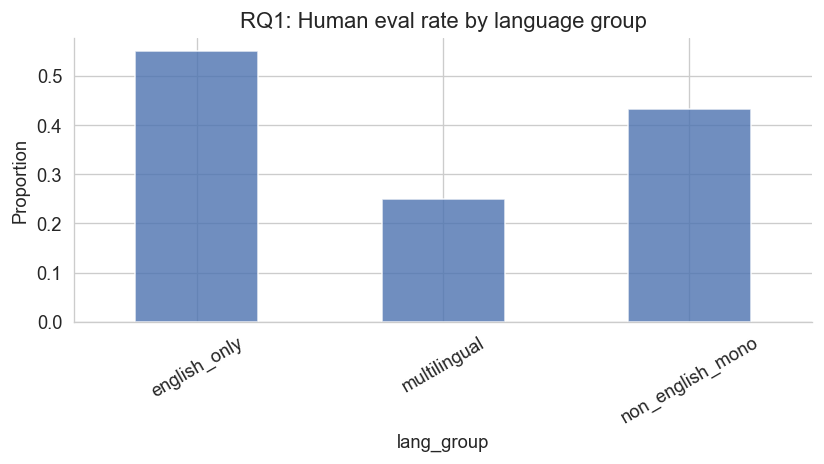

In [77]:
# 1.5 By language group
lang_he = (
    df[df["lang_group"] != "unknown"]
    .groupby("lang_group")["has_human_eval"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "count_he", "count": "total", "mean": "rate"})
)
print("Human eval rate by language group:")
print(lang_he.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
lang_he["rate"].plot(kind="bar", ax=ax, color="#4C72B0", alpha=0.8)
ax.set_title("RQ1: Human eval rate by language group")
ax.set_ylabel("Proportion")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
save_fig(fig, "rq1_by_language")
plt.show()

---
## Section 2 -- RQ2: Adoption of LLM-as-a-Judge

In [78]:
n_llm   = df['has_llm_judge'].sum()
n_instr = df['has_true_llm_judge'].sum()
n_ml    = df['has_ml_judge'].sum()
print(f'Papers with has_llm_judge=True : {n_llm:,} ({n_llm/len(df)*100:.2f}%)')
print(f'  instruction_llm              : {n_instr:,} ({n_instr/max(n_llm,1)*100:.1f}%)')
print(f'  ml_evaluator                 : {n_ml:,} ({n_ml/max(n_llm,1)*100:.1f}%)')
print(f'  unknown type                 : {n_llm-n_instr-n_ml:,}')
print('\nBy year (instruction_llm only):')
print(df.groupby('year')['has_true_llm_judge']
      .agg(['sum', 'count', 'mean'])
      .rename(columns={'sum': 'count_instr', 'count': 'total', 'mean': 'rate'})
      .to_string())

Papers with has_llm_judge=True : 237 (1.44%)
  instruction_llm              : 120 (50.6%)
  ml_evaluator                 : 8 (3.4%)
  unknown type                 : 109

By year (instruction_llm only):
      count_instr  total      rate
year                              
1952            0      7  0.000000
1956            0      4  0.000000
1957            0      2  0.000000
1960            0      1  0.000000
1961            0      1  0.000000
1962            0      5  0.000000
1963            0      1  0.000000
1965            0      2  0.000000
1967            0      3  0.000000
1969            0      3  0.000000
1971            0      3  0.000000
1974            0      1  0.000000
1975            0      1  0.000000
1976            0      3  0.000000
1977            0      1  0.000000
1978            0      4  0.000000
1979            0      1  0.000000
1980            0      7  0.000000
1981            0     10  0.000000
1982            0      9  0.000000
1983            0     18  0.

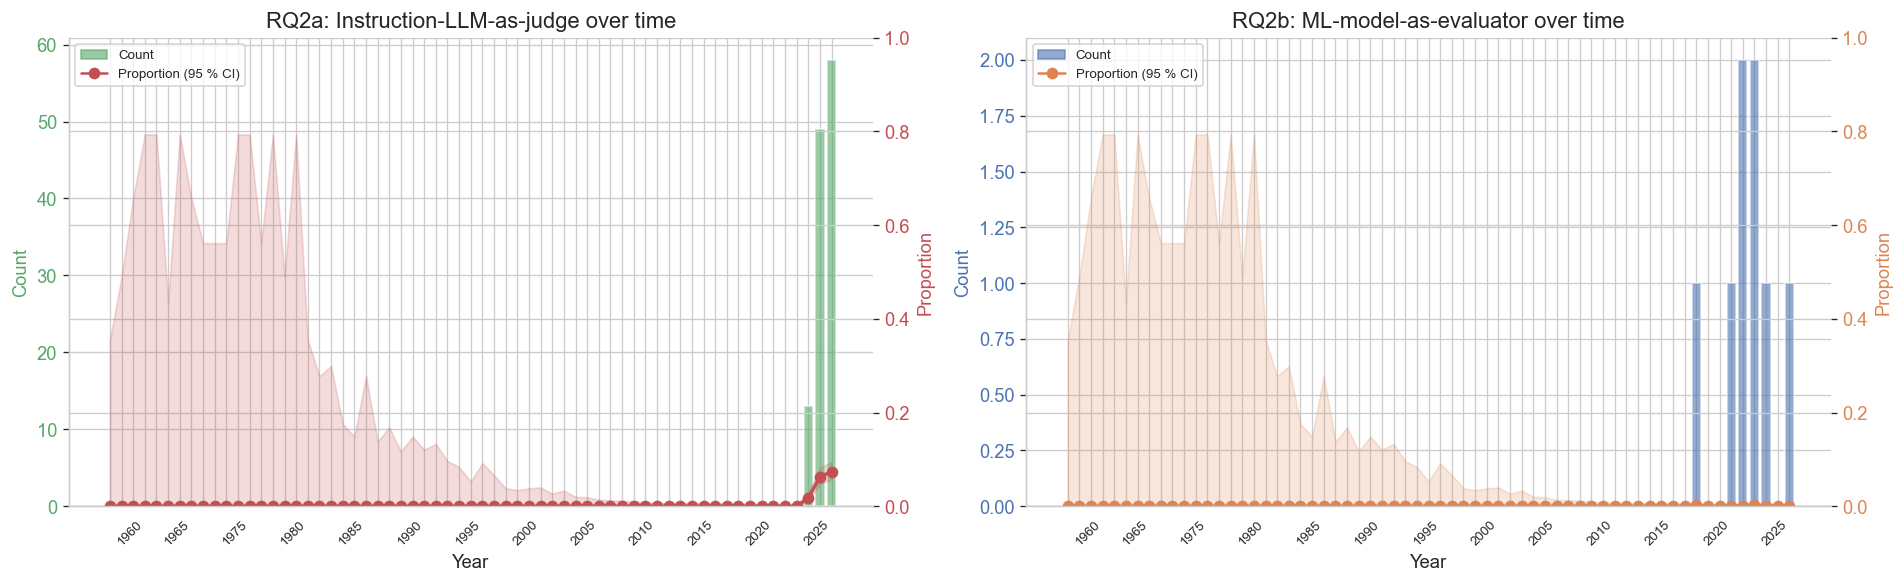

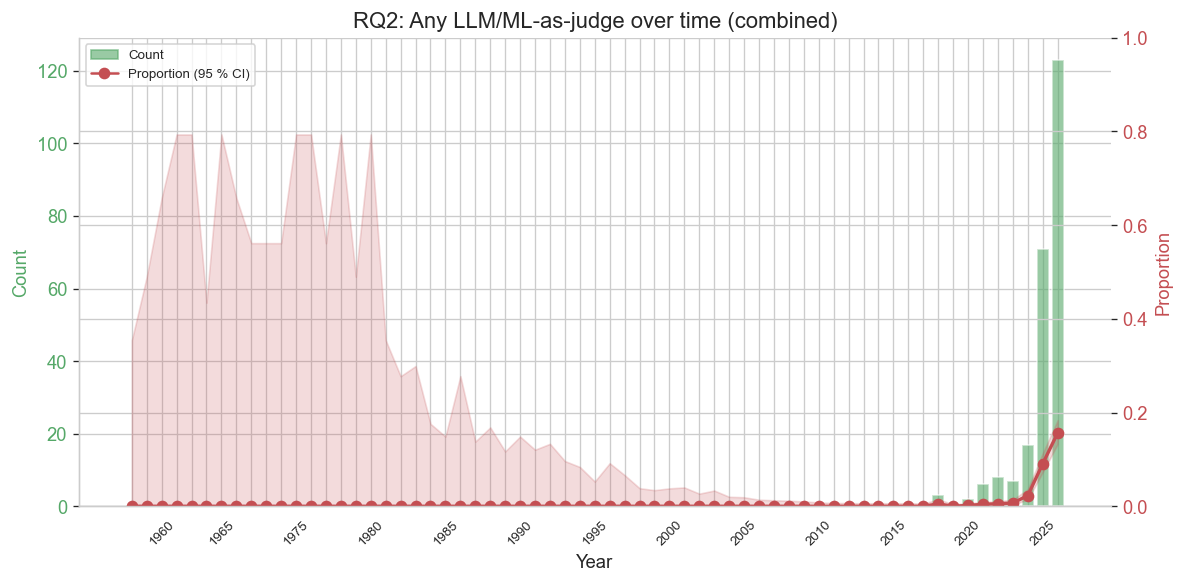

In [79]:
# 2.1 Emergence timeline -- instruction_llm vs ml_evaluator
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dual_axis_trend(df, 'year', 'has_true_llm_judge',
                'RQ2a: Instruction-LLM-as-judge over time', ax=axes[0],
                color_bar='#55A868', color_line='#C44E52')

dual_axis_trend(df, 'year', 'has_ml_judge',
                'RQ2b: ML-model-as-evaluator over time', ax=axes[1],
                color_bar='#4C72B0', color_line='#DD8452')

plt.tight_layout()
save_fig(fig, 'rq2_judge_timeline_by_type')
plt.show()

# Combined view for reference
fig2, ax2 = plt.subplots(figsize=(10, 5))
dual_axis_trend(df, 'year', 'has_llm_judge',
                'RQ2: Any LLM/ML-as-judge over time (combined)', ax=ax2,
                color_bar='#55A868', color_line='#C44E52')
plt.tight_layout()
save_fig(fig2, 'rq2_llm_judge_timeline')
plt.show()

In [80]:
# 2.2 First occurrence per venue
for vg in VENUE_GROUPS:
    sub = df[(df['has_true_llm_judge']) & (df['venue_group'] == vg)]
    if len(sub) == 0:
        print(f"{vg}: no instruction-LLM-judge papers")
        continue
    first = sub.sort_values('year').iloc[0]
    print(f"{vg}: first in {first['year']} -- {first['title'][:80]}")

generation: first in 2023 -- Generating Faithful Text From a Knowledge Graph with Noisy Reference Text
core_nlp: first in 2023 -- INSTRUCTSCORE: Towards Explainable Text Generation Evaluation with Automatic Fee
journals: first in 2024 -- Cross-lingual Cross-temporal Summarization: Dataset, Models, Evaluation


Top judge models (all):
llm_judge_model
GPT-4                                 37
LLM                                   24
GPT-4o                                18
ChatGPT                               11
LLMs                                   6
Gemini                                 3
GPT-4o-mini                            3
GPT4                                   3
not specified                          2
GPT-eval                               2
GPT-2                                  1
gpt-3.5-turbo-0301, gpt-4-0314         1
instruction-tuned PLM                  1
LLMs such as ChatGPT                   1
AfroXLMR-114L                          1
GPT-4, GPT-3                           1
GPT-3.5-turbo-0125, Gemini-1.0-Pro     1
LLM-as-a-Judge                         1
LLM3.75                                1
LLaVA                                  1


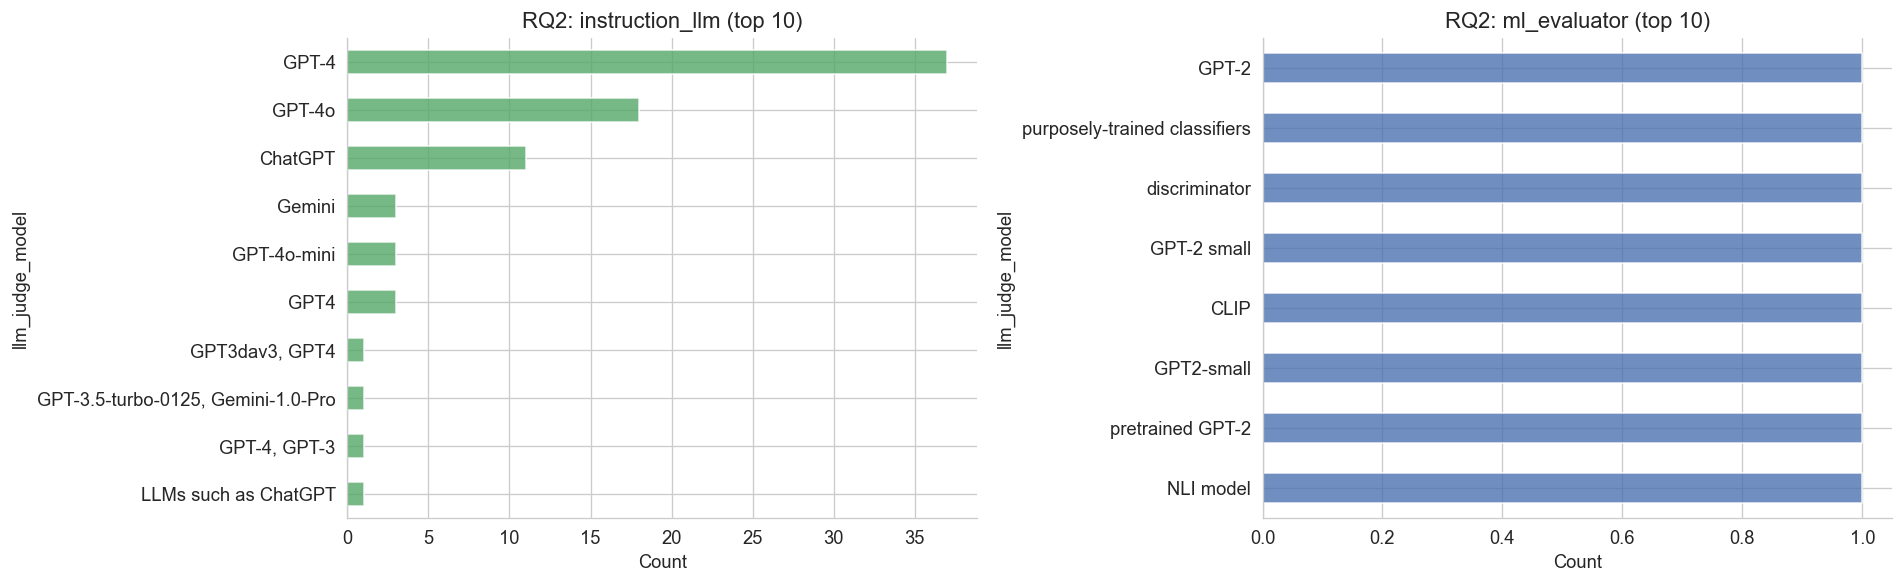

In [81]:
# 2.3 Which LLMs are used as judges (by type)?
llm_models = (
    df[df['has_llm_judge'] & df['llm_judge_model'].notna()]
    ['llm_judge_model']
    .value_counts()
)
print('Top judge models (all):')
print(llm_models.head(20).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, jtype, col in [
    (axes[0], 'instruction_llm', '#55A868'),
    (axes[1], 'ml_evaluator',    '#4C72B0'),
]:
    sub = df[(df['llm_judge_type'] == jtype) & df['llm_judge_model'].notna()]
    vc = sub['llm_judge_model'].value_counts().head(10)
    if len(vc) == 0:
        ax.set_title(f'{jtype}: no data')
        continue
    vc.plot(kind='barh', ax=ax, color=col, alpha=0.8)
    ax.set_title(f'RQ2: {jtype} (top 10)')
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.tight_layout()
save_fig(fig, 'rq2_judge_models_by_type')
plt.show()


instruction_llm rate by task (min 20 papers):
                     count  total      rate
task                                       
code_generation          7    135  0.051852
data_to_text             6    166  0.036145
story_generation         2     61  0.032787
question_generation      5    261  0.019157
summarization           26   1659  0.015672
simplification           2    148  0.013514
general_nlg             11   1019  0.010795
dialogue                13   1223  0.010630
style_transfer           1     97  0.010309
paraphrase               6    621  0.009662

ml_evaluator rate by task (min 20 papers):
                     count  total      rate
task                                       
captioning               1    216  0.004630
question_generation      1    261  0.003831
dialogue                 2   1223  0.001635
paraphrase               1    621  0.001610
summarization            1   1659  0.000603
code_generation          0    135  0.000000
data_to_text             0   

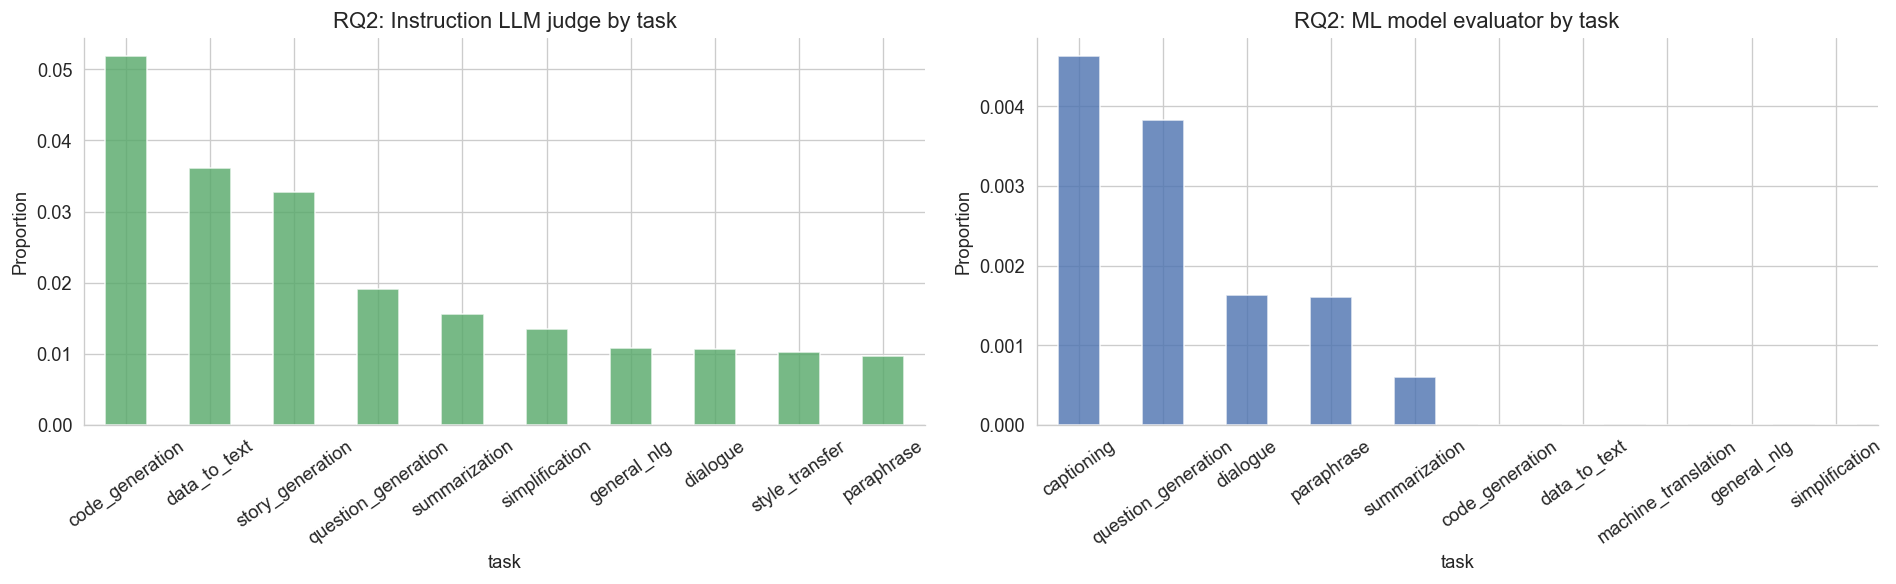

In [82]:
# 2.4 Task breakdown -- instruction_llm vs ml_evaluator
for col, label in [('has_true_llm_judge', 'instruction_llm'), ('has_ml_judge', 'ml_evaluator')]:
    tbl = (
        df_single.groupby('task')[col]
        .agg(['sum', 'count', 'mean'])
        .rename(columns={'sum': 'count', 'count': 'total', 'mean': 'rate'})
        .query('total >= 20')
        .sort_values('rate', ascending=False)
    )
    print(f'\n{label} rate by task (min 20 papers):')
    print(tbl.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, label, color in [
    (axes[0], 'has_true_llm_judge', 'Instruction LLM judge', '#55A868'),
    (axes[1], 'has_ml_judge',       'ML model evaluator',    '#4C72B0'),
]:
    tbl = (
        df_single.groupby('task')[col]
        .agg(['sum', 'count', 'mean'])
        .rename(columns={'sum': 'count', 'count': 'total', 'mean': 'rate'})
        .query('total >= 20')
        .sort_values('rate', ascending=False)
    )
    tbl['rate'].head(10).plot(kind='bar', ax=ax, color=color, alpha=0.8)
    ax.set_title(f'RQ2: {label} by task')
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
save_fig(fig, 'rq2_by_task_by_type')
plt.show()

In [83]:
# 2.5 Co-occurrence with human eval / auto eval
llm_p = df[df['has_true_llm_judge']]
print(f"Instruction-LLM-judge papers: {len(llm_p)}")
print(f"  + human eval:  {llm_p['has_human_eval'].sum()} ({llm_p['has_human_eval'].mean()*100:.1f}%)")
print(f"  + auto eval:   {llm_p['has_auto_eval'].sum()} ({llm_p['has_auto_eval'].mean()*100:.1f}%)")
print(f"  all three:     {(llm_p['has_human_eval'] & llm_p['has_auto_eval']).sum()}")

# Over time: is LLM judge replacing or complementing human eval?
llm_yr = df[df['has_true_llm_judge']].groupby('year').apply(
    lambda x: pd.Series({'n': len(x),
                          'pct_also_human': x['has_human_eval'].mean()})
).reset_index()
print("\nInstruction-LLM-judge + human eval co-occurrence over time:")
print(llm_yr.to_string(index=False))

Instruction-LLM-judge papers: 120
  + human eval:  25 (20.8%)
  + auto eval:   89 (74.2%)
  all three:     22

Instruction-LLM-judge + human eval co-occurrence over time:
 year    n  pct_also_human
 2023 13.0        0.538462
 2024 49.0        0.204082
 2025 58.0        0.137931


In [84]:
# 2.6 By language group
print("Instruction-LLM-judge by language group:")
print(
    df[df['lang_group'] != 'unknown']
    .groupby('lang_group')['has_true_llm_judge']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'count_llm', 'count': 'total', 'mean': 'rate'})
    .to_string()
)

Instruction-LLM-judge by language group:
                  count_llm  total      rate
lang_group                                  
english_only              7    930  0.007527
multilingual             15   4285  0.003501
non_english_mono          2    435  0.004598


---
## Section 3 -- RQ3: Trends in Human Evaluation Criteria

In [85]:
he = df[df['has_human_eval'] & df['criteria_norm'].str.strip().astype(bool)].copy()
he_exp = (
    he['criteria_norm']
    .str.split('|').explode().str.strip()
    .replace('', np.nan).dropna()
)
he_per_year = he.groupby('year').size().rename('he_total')

print(f"Human-eval papers with criteria data: {len(he):,}")
print(f"Criteria mentions total: {len(he_exp):,}")

Human-eval papers with criteria data: 3,159
Criteria mentions total: 5,242


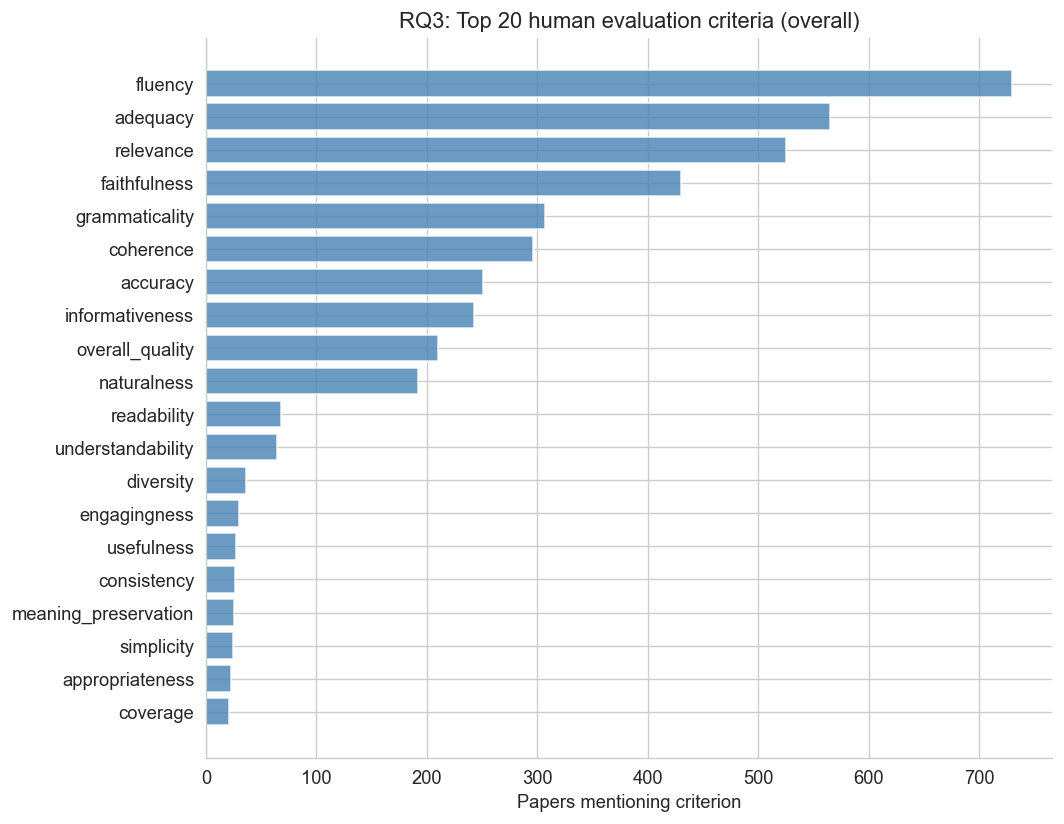

           criterion  count    pct_he
             fluency    730 23.108579
            adequacy    565 17.885407
           relevance    525 16.619183
        faithfulness    430 13.611903
      grammaticality    307  9.718265
           coherence    296  9.370054
            accuracy    251  7.945552
     informativeness    243  7.692308
     overall_quality    210  6.647673
         naturalness    192  6.077873
         readability     68  2.152580
   understandability     64  2.025958
           diversity     36  1.139601
        engagingness     30  0.949668
          usefulness     27  0.854701
         consistency     26  0.823045
meaning_preservation     25  0.791390
          simplicity     24  0.759734
     appropriateness     23  0.728079
            coverage     21  0.664767


In [86]:
# 3.1 Overall frequency ranking
crit_freq = he_exp.value_counts().reset_index()
crit_freq.columns = ['criterion', 'count']
crit_freq['pct_he'] = crit_freq['count'] / len(he) * 100
crit_freq_clean = crit_freq[crit_freq['criterion'] != 'other'].head(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(crit_freq_clean['criterion'][::-1], crit_freq_clean['count'][::-1],
        color='steelblue', alpha=0.8)
ax.set_title('RQ3: Top 20 human evaluation criteria (overall)')
ax.set_xlabel('Papers mentioning criterion')
plt.tight_layout()
save_fig(fig, 'rq3_criteria_overall')
plt.show()
print(crit_freq_clean.to_string(index=False))

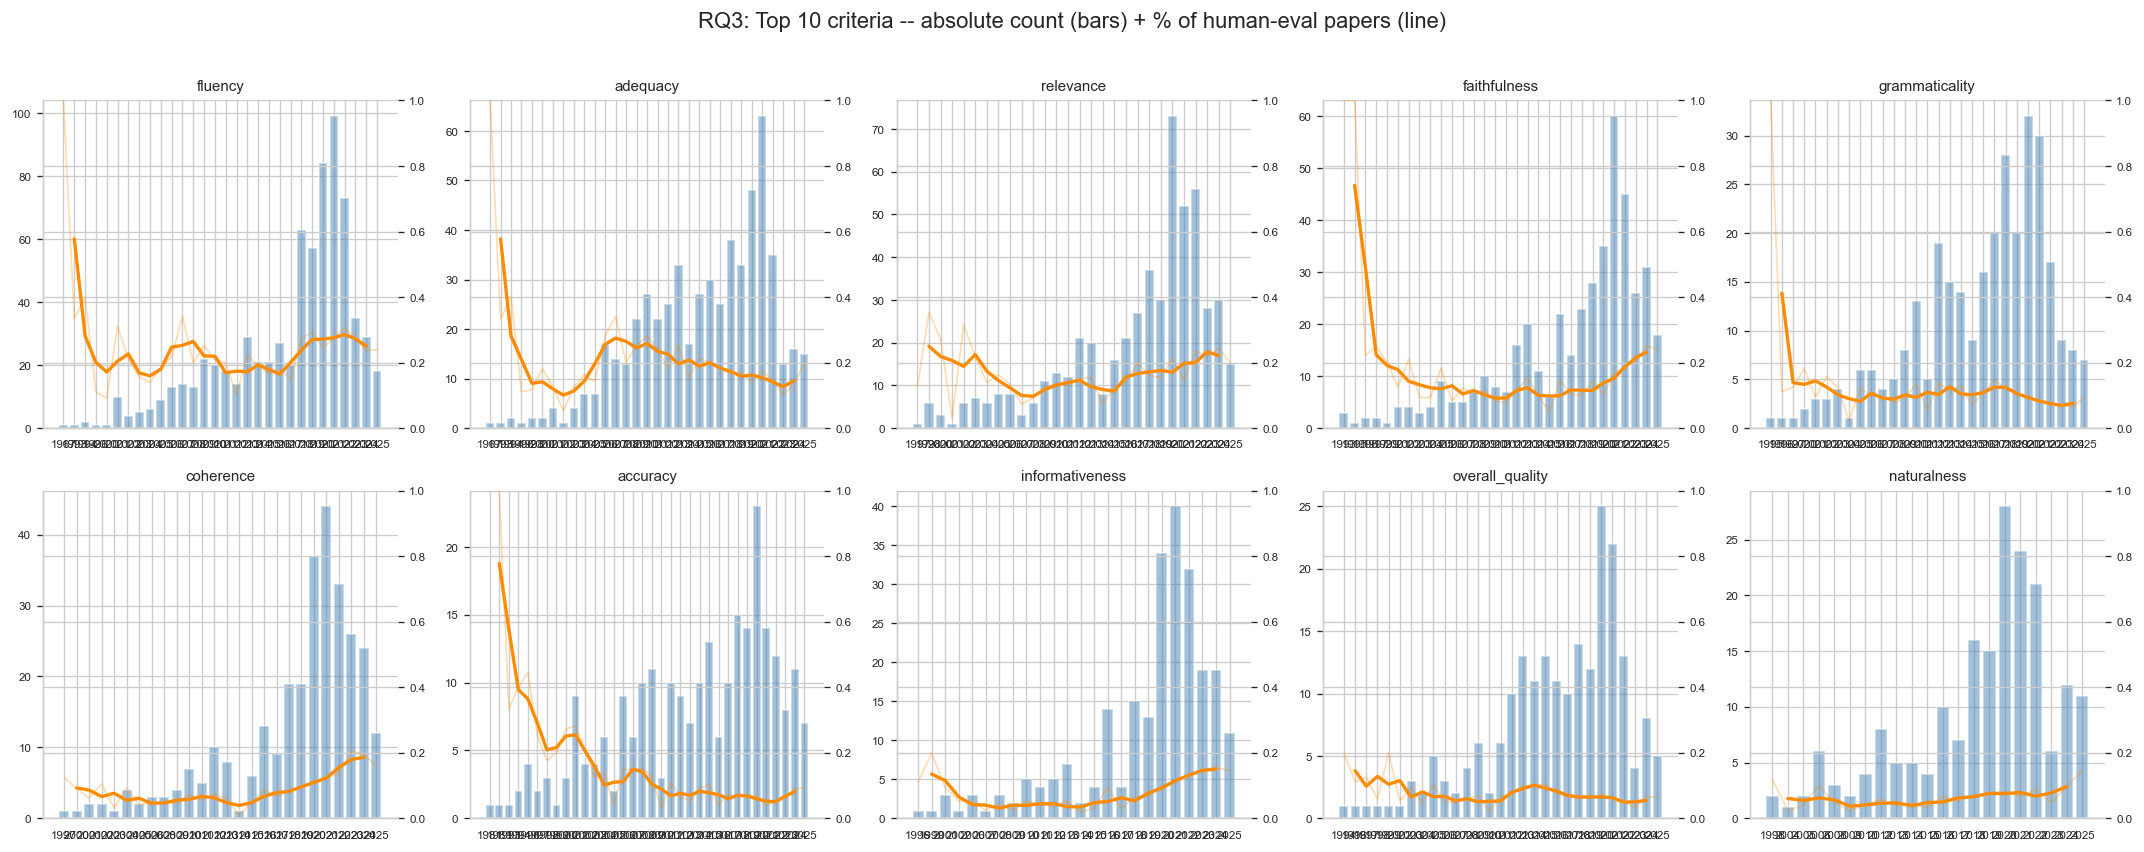

In [87]:
# 3.2 Criteria over time (top 10)
TOP_CRITERIA = crit_freq_clean['criterion'].head(10).tolist()

crit_yr_exp = (
    he[['year', 'criteria_norm']]
    .assign(criterion=he['criteria_norm'].str.split('|'))
    .explode('criterion')
    .assign(criterion=lambda x: x['criterion'].str.strip())
)
crit_yr_top = crit_yr_exp[crit_yr_exp['criterion'].isin(TOP_CRITERIA)]
crit_by_year = (
    crit_yr_top.groupby(['year', 'criterion']).size()
    .reset_index(name='count')
    .merge(he_per_year, on='year')
    .assign(rate=lambda x: x['count'] / x['he_total'])
)

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
for ax, crit in zip(axes.flatten(), TOP_CRITERIA):
    sub = crit_by_year[crit_by_year['criterion'] == crit].sort_values('year')
    ax.bar(sub['year'].astype(str), sub['count'], color='steelblue', alpha=0.5)
    ax2 = ax.twinx()
    # 3-year rolling average on proportions
    if len(sub) >= 3:
        sub = sub.copy()
        sub['rate_smooth'] = sub['rate'].rolling(3, center=True).mean()
        ax2.plot(range(len(sub)), sub['rate_smooth'], color='darkorange', linewidth=2)
    ax2.plot(range(len(sub)), sub['rate'], color='darkorange', alpha=0.3, linewidth=1)
    ax2.set_ylim(0, 1)
    ax.set_title(crit, fontsize=9)
    ax.tick_params(labelsize=7)
    ax2.tick_params(labelsize=7)

plt.suptitle('RQ3: Top 10 criteria -- absolute count (bars) + % of human-eval papers (line)', y=1.01)
plt.tight_layout()
save_fig(fig, 'rq3_criteria_trends')
plt.show()

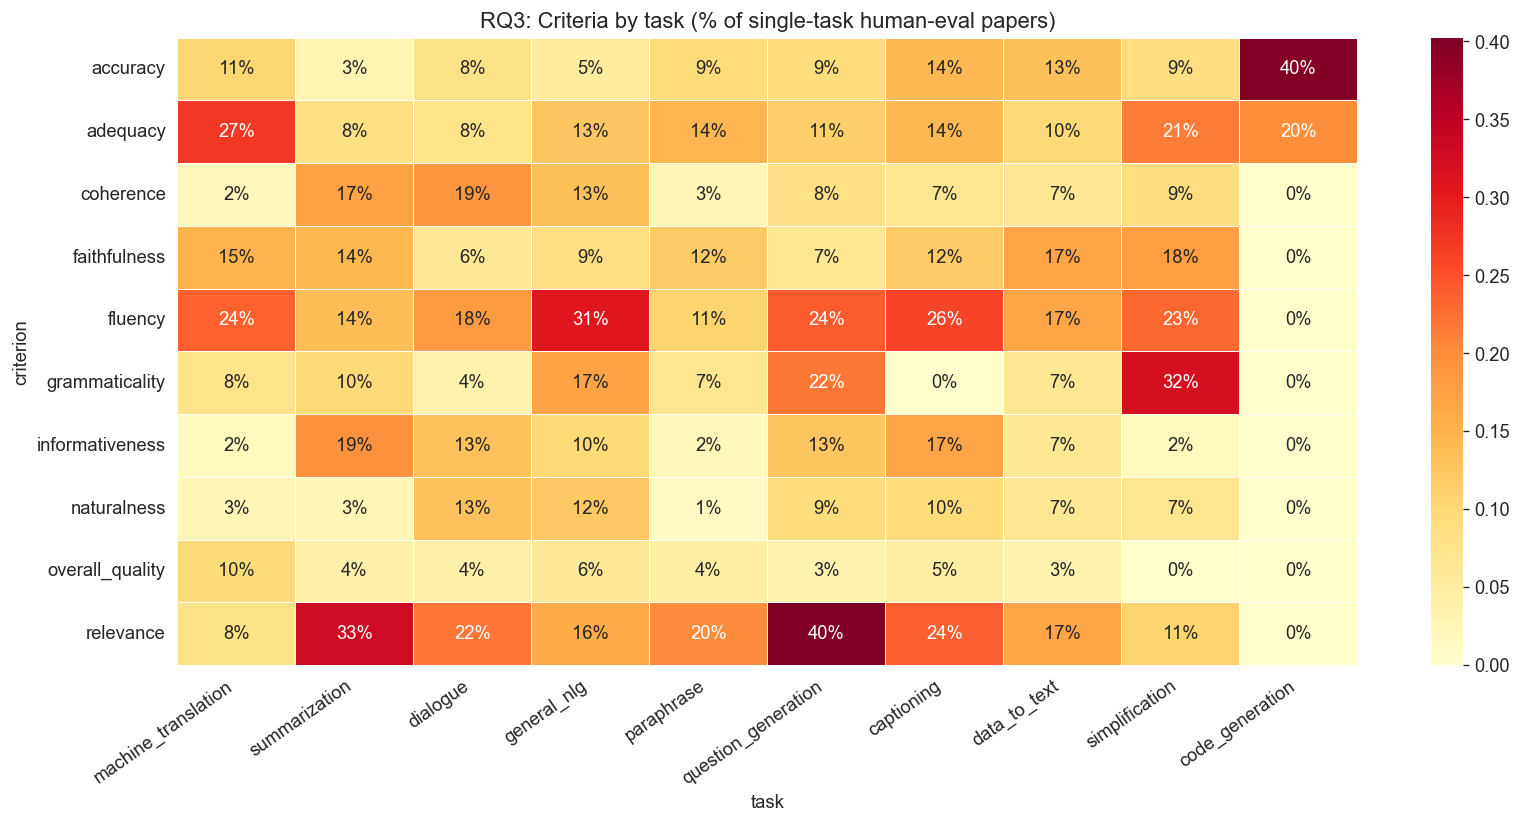

In [88]:
# 3.3 Criteria by task heatmap (df_single)
he_s = df_single[df_single['has_human_eval'] & df_single['criteria_norm'].str.strip().astype(bool)].copy()
he_s_exp = (
    he_s[['task', 'criteria_norm']]
    .assign(criterion=he_s['criteria_norm'].str.split('|'))
    .explode('criterion')
    .assign(criterion=lambda x: x['criterion'].str.strip())
)
he_s_exp = he_s_exp[he_s_exp['criterion'].isin(TOP_CRITERIA)]
he_per_task = he_s.groupby('task').size().rename('he_total')
crit_by_task = (
    he_s_exp.groupby(['task', 'criterion']).size()
    .reset_index(name='count')
    .merge(he_per_task, on='task')
    .assign(rate=lambda x: x['count'] / x['he_total'])
)
top_tasks_10 = df_single['task'].value_counts().head(10).index
pivot_ct = (
    crit_by_task.pivot(index='criterion', columns='task', values='rate')
    .fillna(0)
    .reindex(columns=[t for t in top_tasks_10 if t in crit_by_task['task'].unique()])
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot_ct, annot=True, fmt='.0%', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('RQ3: Criteria by task (% of single-task human-eval papers)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
save_fig(fig, 'rq3_criteria_by_task')
plt.show()

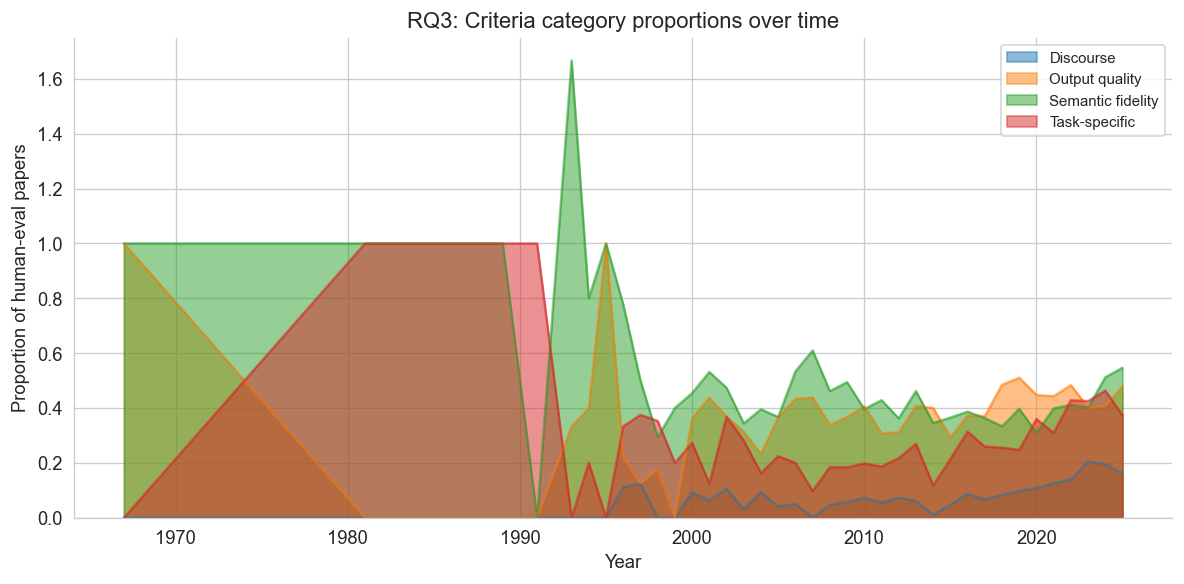

In [89]:
# 3.4 Criteria grouping over time (stacked area)
CRITERIA_GROUPS = {
    'Output quality':    ['fluency', 'grammaticality', 'naturalness', 'readability'],
    'Semantic fidelity': ['adequacy', 'faithfulness', 'accuracy', 'consistency'],
    'Discourse':         ['coherence', 'cohesion', 'structure'],
    'Task-specific':     ['relevance', 'informativeness', 'engagingness',
                          'simplicity', 'understandability', 'coverage'],
}

def _assign_group(crit):
    for grp, members in CRITERIA_GROUPS.items():
        if crit in members:
            return grp
    return None

crit_full_exp = (
    he[['year', 'criteria_norm']]
    .assign(criterion=he['criteria_norm'].str.split('|'))
    .explode('criterion')
    .assign(criterion=lambda x: x['criterion'].str.strip())
)
crit_full_exp['group'] = crit_full_exp['criterion'].apply(_assign_group)
crit_full_exp = crit_full_exp.dropna(subset=['group'])

grp_yr = (
    crit_full_exp.groupby(['year', 'group']).size()
    .reset_index(name='count')
    .merge(he_per_year, on='year')
    .assign(rate=lambda x: x['count'] / x['he_total'])
)
pivot_grp = (
    grp_yr.pivot(index='year', columns='group', values='rate')
    .fillna(0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
pivot_grp.plot(kind='area', stacked=False, ax=ax, alpha=0.5)
ax.set_title('RQ3: Criteria category proportions over time')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion of human-eval papers')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
save_fig(fig, 'rq3_criteria_groups')
plt.show()

---
## Section 4 -- RQ3b: Trends in Human Evaluation Methods

In [90]:
he_m = df[df['has_human_eval'] & df['methods_norm'].str.strip().astype(bool)].copy()
meth_exp = (
    he_m['methods_norm'].str.split('|').explode().str.strip()
    .replace('', np.nan).dropna()
)
meth_freq = meth_exp.value_counts().reset_index()
meth_freq.columns = ['method', 'count']
meth_freq['pct_he'] = meth_freq['count'] / len(he_m) * 100

print(f"Human-eval papers with method info: {len(he_m):,}")
print(meth_freq.to_string(index=False))

Human-eval papers with method info: 4,034
               method  count    pct_he
binary_classification   1286 31.879028
                other    773 19.162122
              ranking    753 18.666336
         likert_scale    583 14.452157
  pairwise_comparison    352  8.725830
            free_text    200  4.957858
error_span_annotation    174  4.313337
         post_editing     98  2.429351
    direct_assessment     50  1.239465
                  MQM     21  0.520575
   best_worst_scaling     18  0.446207
         crowdsourced     13  0.322261


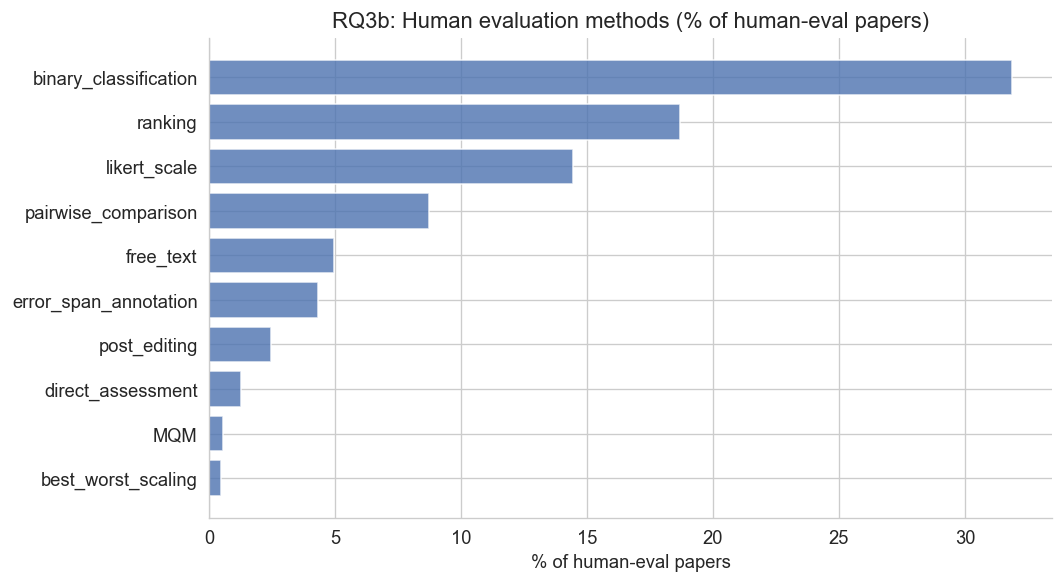

In [91]:
# 4.1 Overall frequency
fig, ax = plt.subplots(figsize=(9, 5))
top_meth = meth_freq[meth_freq['method'] != 'other'].head(10)
ax.barh(top_meth['method'][::-1], top_meth['pct_he'][::-1], color='#4C72B0', alpha=0.8)
ax.set_title('RQ3b: Human evaluation methods (% of human-eval papers)')
ax.set_xlabel('% of human-eval papers')
plt.tight_layout()
save_fig(fig, 'rq3b_methods_overall')
plt.show()

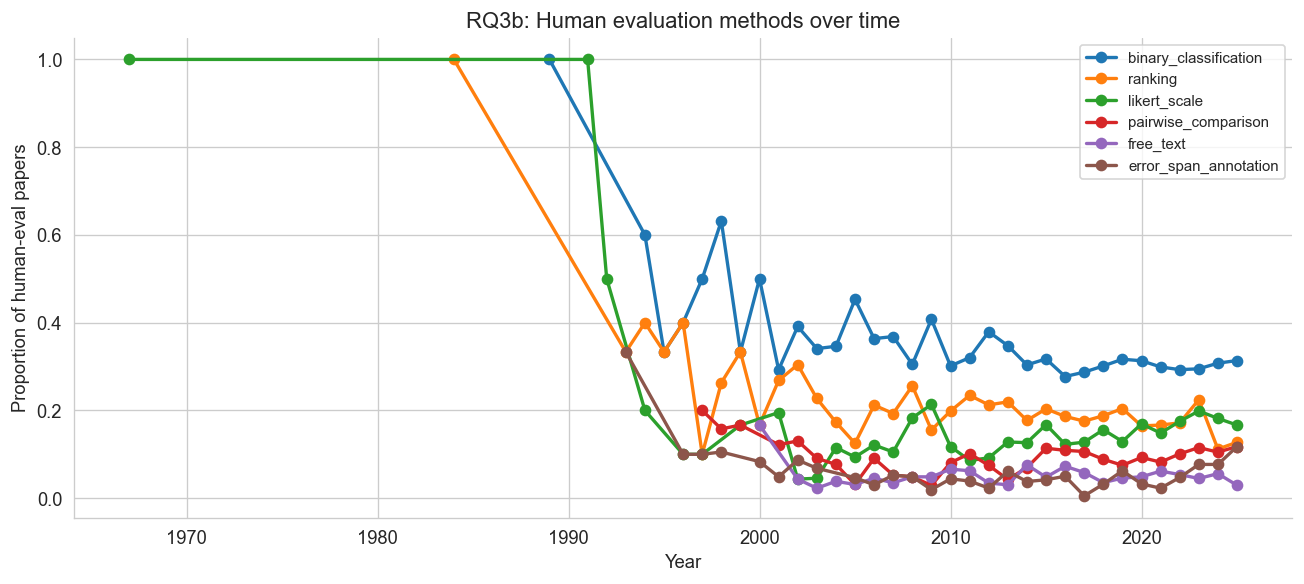

In [92]:
# 4.2 Methods over time
TOP_METHODS = meth_freq[meth_freq['method'] != 'other']['method'].head(6).tolist()

meth_yr_exp = (
    he_m[['year', 'methods_norm']]
    .assign(method=he_m['methods_norm'].str.split('|'))
    .explode('method')
    .assign(method=lambda x: x['method'].str.strip())
)
he_m_per_year = he_m.groupby('year').size().rename('he_total')
meth_yr = (
    meth_yr_exp[meth_yr_exp['method'].isin(TOP_METHODS)]
    .groupby(['year', 'method']).size()
    .reset_index(name='count')
    .merge(he_m_per_year, on='year')
    .assign(rate=lambda x: x['count'] / x['he_total'])
)

fig, ax = plt.subplots(figsize=(11, 5))
for method in TOP_METHODS:
    sub = meth_yr[meth_yr['method'] == method].sort_values('year')
    ax.plot(sub['year'], sub['rate'], marker='o', label=method, linewidth=2)
ax.set_title('RQ3b: Human evaluation methods over time')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion of human-eval papers')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig(fig, 'rq3b_methods_trends')
plt.show()

MT single-task papers with human eval and MT methods: 253


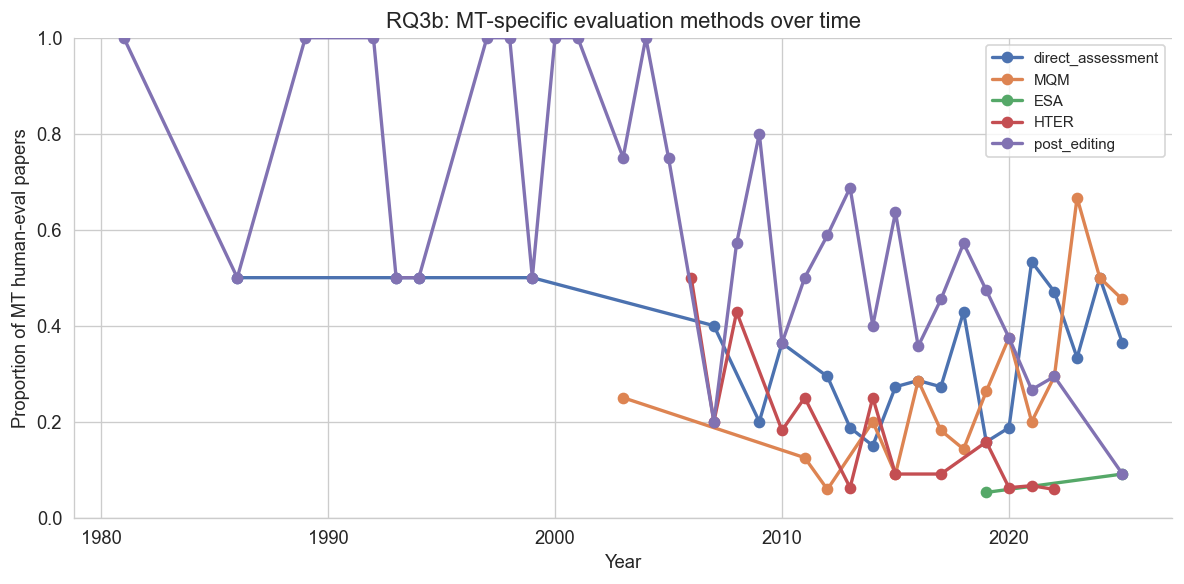

In [93]:
# 4.3 MT-specific methods (DA vs MQM vs ESA vs post-editing)
mt_he = df_single[
    (df_single['task'] == 'machine_translation')
    & df_single['has_human_eval']
    & df_single['mt_methods_norm'].str.strip().astype(bool)
].copy()
print(f"MT single-task papers with human eval and MT methods: {len(mt_he)}")

MT_KEY = ['direct_assessment', 'MQM', 'ESA', 'HTER', 'post_editing']
mt_yr_exp = (
    mt_he[['year', 'mt_methods_norm']]
    .assign(m=mt_he['mt_methods_norm'].str.split('|'))
    .explode('m')
    .assign(m=lambda x: x['m'].str.strip())
)
mt_he_yr = mt_he.groupby('year').size().rename('total')
mt_yr = (
    mt_yr_exp[mt_yr_exp['m'].isin(MT_KEY)]
    .groupby(['year', 'm']).size()
    .reset_index(name='count')
    .merge(mt_he_yr, on='year')
    .assign(rate=lambda x: x['count'] / x['total'])
)

fig, ax = plt.subplots(figsize=(10, 5))
for method, color in zip(MT_KEY, ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']):
    sub = mt_yr[mt_yr['m'] == method].sort_values('year')
    if len(sub) == 0: continue
    ax.plot(sub['year'], sub['rate'], marker='o', label=method, color=color, linewidth=2)
ax.set_title('RQ3b: MT-specific evaluation methods over time')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion of MT human-eval papers')
ax.legend(fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
save_fig(fig, 'rq3b_mt_methods')
plt.show()

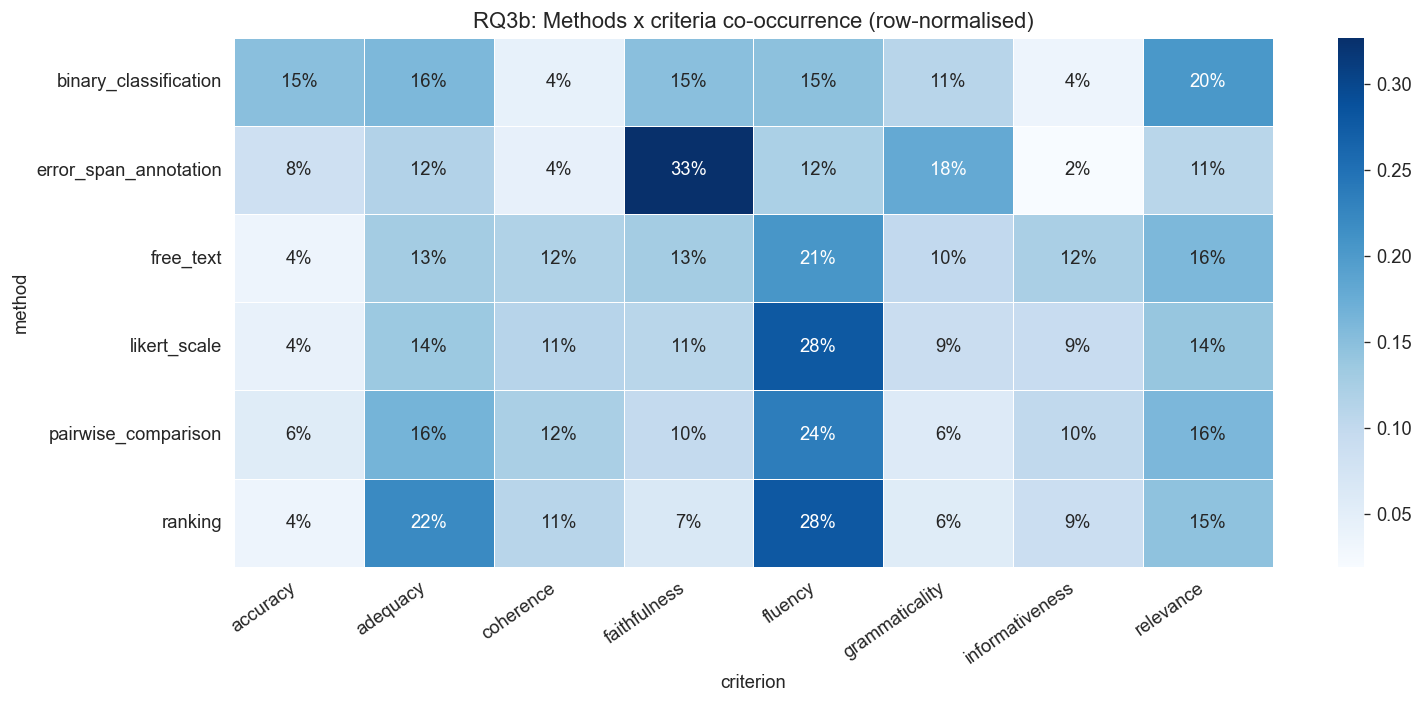

In [94]:
# 4.4 Methods x criteria co-occurrence heatmap
he_both = df[
    df['has_human_eval']
    & df['methods_norm'].str.strip().astype(bool)
    & df['criteria_norm'].str.strip().astype(bool)
].copy()

TOP_M_CO = meth_freq[meth_freq['method'] != 'other']['method'].head(6).tolist()
TOP_C_CO = crit_freq_clean['criterion'].head(8).tolist()

rows = []
for _, row in he_both.iterrows():
    ms = [m.strip() for m in str(row['methods_norm']).split('|') if m.strip() in TOP_M_CO]
    cs = [c.strip() for c in str(row['criteria_norm']).split('|') if c.strip() in TOP_C_CO]
    rows.extend({'method': m, 'criterion': c} for m in ms for c in cs)

co_df = pd.DataFrame(rows)
if len(co_df) > 0:
    co_pivot = co_df.groupby(['method', 'criterion']).size().unstack(fill_value=0)
    co_pct   = co_pivot.div(co_pivot.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.heatmap(co_pct, annot=True, fmt='.0%', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title('RQ3b: Methods x criteria co-occurrence (row-normalised)')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    save_fig(fig, 'rq3b_methods_criteria_cooccurrence')
    plt.show()

---
## Section 5 -- RQ4: Evaluation Modality Distribution Over Time

In [95]:
def assign_eval_type(row):
    h, a, l = row['has_human_eval'], row['has_auto_eval'], row['has_llm_judge']
    if not h and not a and not l:
        return 'none'
    return '+'.join(
        [x for x, flag in [('human', h), ('auto', a), ('llm_judge', l)] if flag]
    )

def simplify_eval_type(row):
    h, a, l = row['has_human_eval'], row['has_auto_eval'], row['has_llm_judge']
    if l and not h:         return 'llm_judge_no_human'
    if h and a:             return 'both_human_auto'
    if h and not a:         return 'human_only'
    if a and not h and not l: return 'auto_only'
    return 'none'

for frame in (df, df_single, df_tasks):
    frame['eval_type']  = frame.apply(assign_eval_type, axis=1)
    frame['eval_type4'] = frame.apply(simplify_eval_type, axis=1)

print("Detailed eval_type distribution:")
print(df['eval_type'].value_counts().to_string())
print("\nSimplified 4-group:")
print(df['eval_type4'].value_counts().to_string())

Detailed eval_type distribution:
eval_type
auto                    7787
none                    4408
human+auto              2306
human                   1744
auto+llm_judge           124
llm_judge                 74
human+auto+llm_judge      34
human+llm_judge            5

Simplified 4-group:
eval_type4
auto_only             7787
none                  4408
both_human_auto       2340
human_only            1749
llm_judge_no_human     198


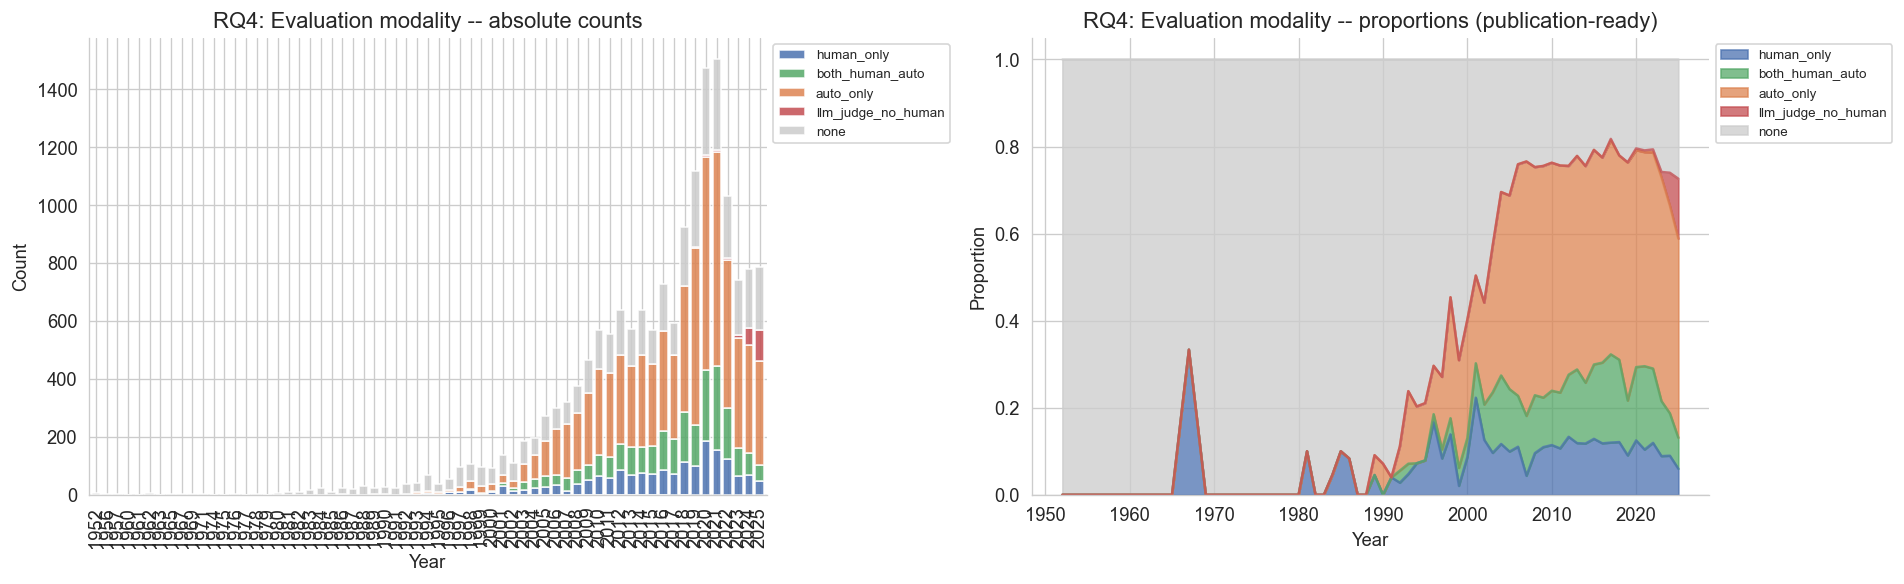

eval_type4  human_only  both_human_auto  auto_only  llm_judge_no_human   none
year                                                                         
1952             0.000            0.000      0.000               0.000  1.000
1956             0.000            0.000      0.000               0.000  1.000
1957             0.000            0.000      0.000               0.000  1.000
1960             0.000            0.000      0.000               0.000  1.000
1961             0.000            0.000      0.000               0.000  1.000
1962             0.000            0.000      0.000               0.000  1.000
1963             0.000            0.000      0.000               0.000  1.000
1965             0.000            0.000      0.000               0.000  1.000
1967             0.333            0.000      0.000               0.000  0.667
1969             0.000            0.000      0.000               0.000  1.000
1971             0.000            0.000      0.000              

In [96]:
ET4_ORDER  = ['human_only', 'both_human_auto', 'auto_only', 'llm_judge_no_human', 'none']
ET4_COLORS = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#CCCCCC']

et_year = (
    df.groupby(['year', 'eval_type4']).size()
    .unstack(fill_value=0)
    .reindex(columns=ET4_ORDER, fill_value=0)
)
et_year_pct = et_year.div(et_year.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
et_year.plot(kind='bar', stacked=True, ax=axes[0], color=ET4_COLORS, alpha=0.85, width=0.8)
axes[0].set_title('RQ4: Evaluation modality -- absolute counts')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8, bbox_to_anchor=(1, 1))

et_year_pct.plot(kind='area', stacked=True, ax=axes[1], color=ET4_COLORS, alpha=0.75)
axes[1].set_title('RQ4: Evaluation modality -- proportions (publication-ready)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Proportion')
axes[1].legend(fontsize=8, bbox_to_anchor=(1, 1))

plt.tight_layout()
save_fig(fig, 'rq4_eval_modality')
plt.show()
print(et_year_pct.round(3).to_string())

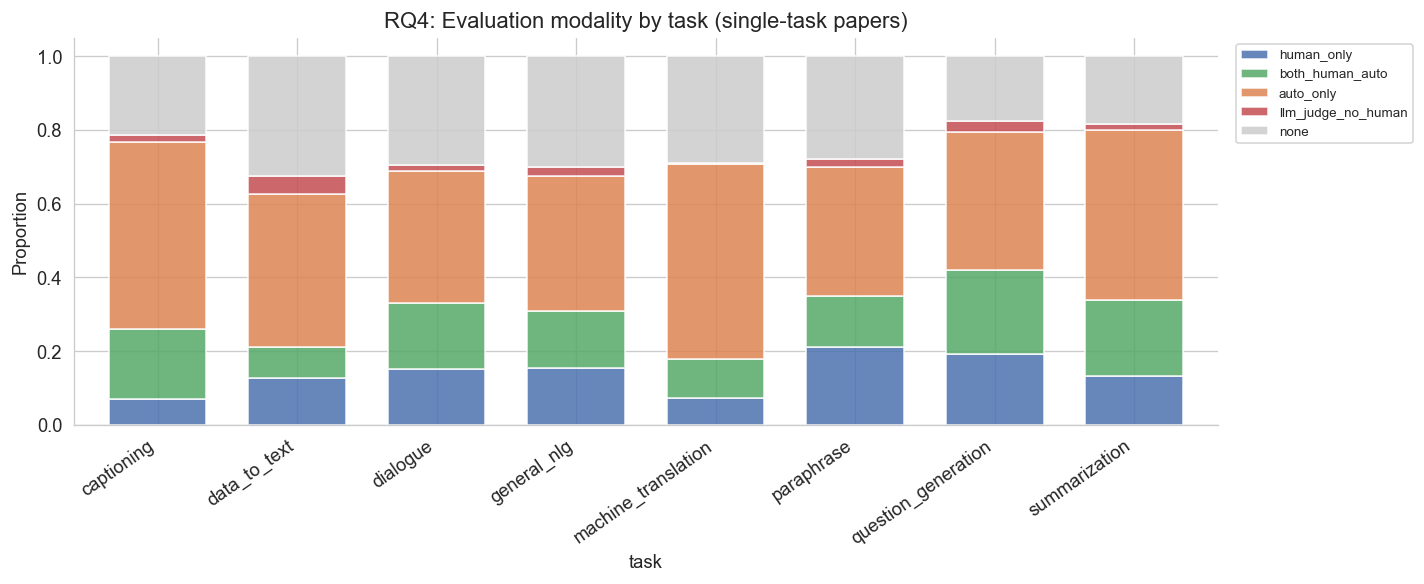

In [97]:
# 5.2 By task (df_single)
top8_tasks = df_single['task'].value_counts().head(8).index
task_et = (
    df_single[df_single['task'].isin(top8_tasks)]
    .groupby(['task', 'eval_type4']).size()
    .unstack(fill_value=0)
    .reindex(columns=ET4_ORDER, fill_value=0)
)
task_et_pct = task_et.div(task_et.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
task_et_pct.plot(kind='bar', stacked=True, ax=ax, color=ET4_COLORS, alpha=0.85, width=0.7)
ax.set_title('RQ4: Evaluation modality by task (single-task papers)')
ax.set_ylabel('Proportion')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
save_fig(fig, 'rq4_by_task')
plt.show()

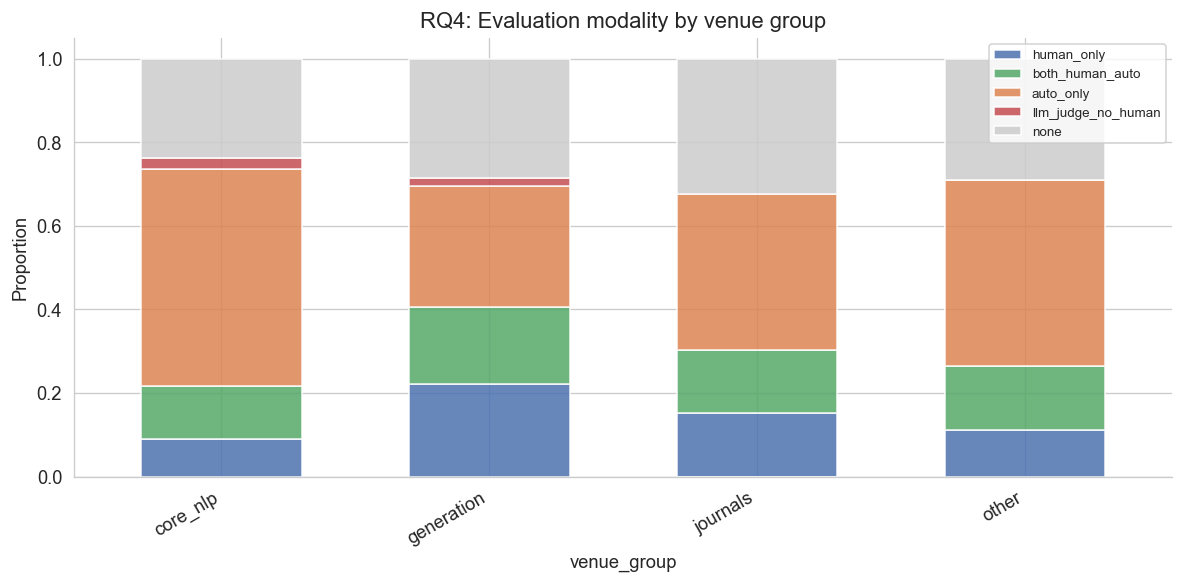


Pairwise chi-squared tests (human-involving vs auto-only):
  journals vs other: chi2=8.36, p=0.0153, p_bonf=0.0918
  journals vs core_nlp: chi2=28.92, p=0.0000, p_bonf=0.0000
  journals vs generation: chi2=10.21, p=0.0061, p_bonf=0.0364
  other vs core_nlp: chi2=78.42, p=0.0000, p_bonf=0.0000
  other vs generation: chi2=67.67, p=0.0000, p_bonf=0.0000
  core_nlp vs generation: chi2=129.28, p=0.0000, p_bonf=0.0000


In [98]:
# 5.3 By venue group
vg_et = (
    df.groupby(['venue_group', 'eval_type4']).size()
    .unstack(fill_value=0)
    .reindex(columns=ET4_ORDER, fill_value=0)
)
vg_et_pct = vg_et.div(vg_et.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
vg_et_pct.plot(kind='bar', stacked=True, ax=ax, color=ET4_COLORS, alpha=0.85, width=0.6)
ax.set_title('RQ4: Evaluation modality by venue group')
ax.set_ylabel('Proportion')
ax.legend(fontsize=8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_fig(fig, 'rq4_by_venue')
plt.show()

# Pairwise chi-squared venue x (human_only + both_human_auto) vs auto_only
print("\nPairwise chi-squared tests (human-involving vs auto-only):")
from itertools import combinations
from scipy.stats import chi2_contingency
vgs = [v for v in df['venue_group'].unique() if v in vg_et.index]
for v1, v2 in combinations(vgs, 2):
    r1 = vg_et.loc[v1, ['human_only', 'both_human_auto', 'auto_only']]
    r2 = vg_et.loc[v2, ['human_only', 'both_human_auto', 'auto_only']]
    table = np.vstack([r1.values, r2.values])
    chi2, p, _, _ = chi2_contingency(table)
    bonf = p * len(vgs) * (len(vgs)-1) / 2  # Bonferroni
    print(f"  {v1} vs {v2}: chi2={chi2:.2f}, p={p:.4f}, p_bonf={bonf:.4f}")

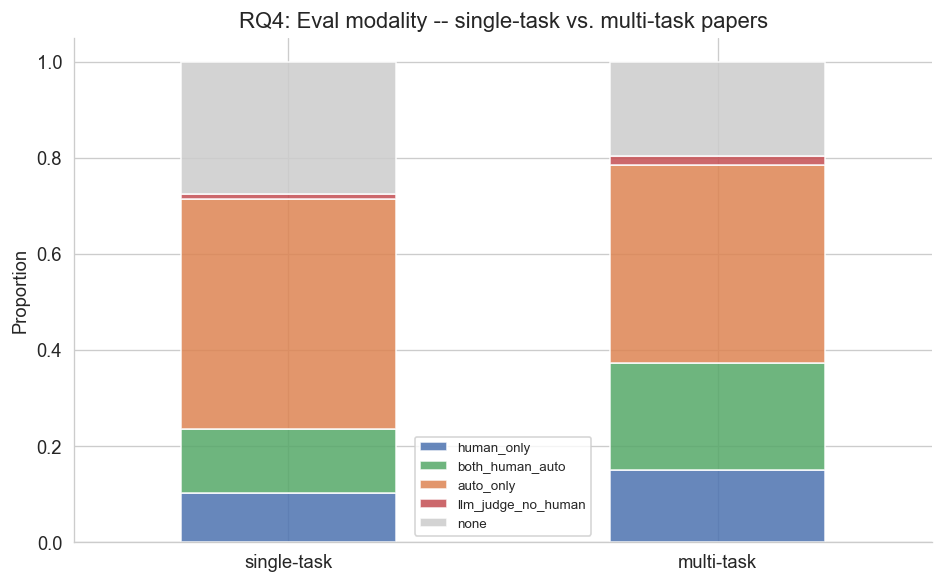

eval_type4   human_only  both_human_auto  auto_only  llm_judge_no_human   none
single-task       0.102            0.134      0.479               0.011  0.275
multi-task        0.150            0.223      0.411               0.020  0.196


In [99]:
# 5.4 Multi-task vs. single-task
mt_et = (
    df.groupby(['is_multi_task', 'eval_type4']).size()
    .unstack(fill_value=0)
    .reindex(columns=ET4_ORDER, fill_value=0)
)
mt_et.index = ['single-task', 'multi-task']
mt_et_pct = mt_et.div(mt_et.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
mt_et_pct.plot(kind='bar', stacked=True, ax=ax, color=ET4_COLORS, alpha=0.85)
ax.set_title('RQ4: Eval modality -- single-task vs. multi-task papers')
ax.set_ylabel('Proportion')
ax.legend(fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
save_fig(fig, 'rq4_multitask_vs_single')
plt.show()
print(mt_et_pct.round(3).to_string())

In [100]:
# 5.5 Logistic regression: has_human_eval ~ year + venue_group + is_multi_task
try:
    import statsmodels.formula.api as smf
    _reg = df.assign(has_human_eval=df['has_human_eval'].astype(int),
                     is_multi_task=df['is_multi_task'].astype(int))
    res = smf.logit(
        'has_human_eval ~ year + C(venue_group) + is_multi_task', data=_reg
    ).fit(disp=False)
    print(res.summary2())
except Exception as e:
    print(f"statsmodels unavailable ({e}). Install with: pip install statsmodels")

statsmodels unavailable (No module named 'statsmodels'). Install with: pip install statsmodels


---
## Section 6 -- RQ5: Decline of BLEU and Metric Succession

In [101]:
ae_papers = df[df['has_auto_eval'] & df['metrics_norm'].str.strip().astype(bool)].copy()
ae_exp_all = (
    ae_papers['metrics_norm'].str.split('|').explode().str.strip()
    .replace('', np.nan).replace('other', np.nan).dropna()
)
ae_per_year = ae_papers.groupby('year').size().rename('ae_total')

print(f"Auto-eval papers with metrics: {len(ae_papers):,}")
print(f"Metric mentions: {len(ae_exp_all):,}")
print("\nTop 30 normalised metrics:")
print(ae_exp_all.value_counts().head(30).to_string())

Auto-eval papers with metrics: 8,871
Metric mentions: 10,476

Top 30 normalised metrics:
metrics_norm
BLEU           4774
ROUGE          1103
METEOR          570
F1              535
Accuracy        516
TER             448
Perplexity      303
NIST            277
Precision       267
Recall          260
WER             255
BERTScore       203
chrF            141
CIDEr           134
COMET            91
RIBES            77
BLEURT           61
PER              56
SARI             51
Exact Match      48
Distinct         44
SPICE            32
Self-BLEU        31
MRR              27
Coverage         24
AER              22
BARTScore        22
Pearson r        21
GTM              20
MoverScore       19


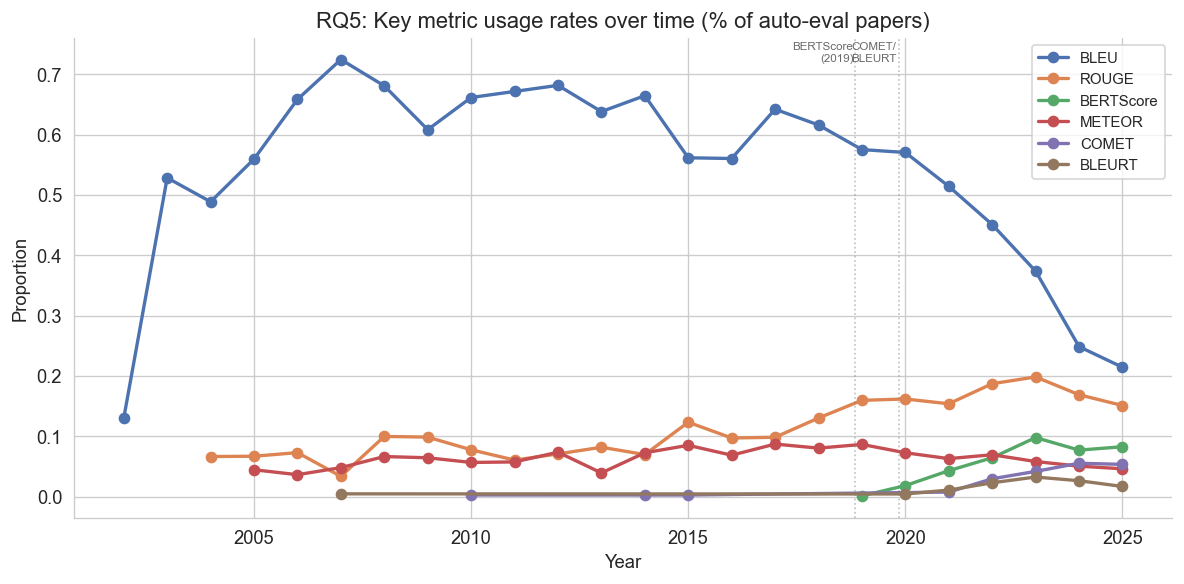

In [102]:
# Build year-metric exploded frame (reused below)
metric_yr_exp = (
    ae_papers[['year', 'metrics_norm']]
    .assign(metric=ae_papers['metrics_norm'].str.split('|'))
    .explode('metric')
    .assign(metric=lambda x: x['metric'].str.strip())
)
metric_yr_exp = metric_yr_exp[metric_yr_exp['metric'] != 'other']

# 6.1 BLEU, ROUGE, BERTScore, METEOR, COMET over time
fig, ax = plt.subplots(figsize=(10, 5))
KEY_METRICS = [('BLEU','#4C72B0'), ('ROUGE','#DD8452'), ('BERTScore','#55A868'),
               ('METEOR','#C44E52'), ('COMET','#8172B2'), ('BLEURT','#937860')]
for metric, color in KEY_METRICS:
    sub = (
        metric_yr_exp[metric_yr_exp['metric'] == metric]
        .groupby('year').size().reset_index(name='count')
        .merge(ae_per_year, on='year')
        .assign(rate=lambda x: x['count'] / x['ae_total'])
    )
    ax.plot(sub['year'], sub['rate'], marker='o', label=metric, color=color, linewidth=2)

for yr, label in [(2019, 'BERTScore\n(2019)'), (2020, 'COMET/\nBLEURT')]:
    ax.axvline(yr - 0.15, color='grey', linestyle=':', alpha=0.5, linewidth=1)
    ax.annotate(label, xy=(yr - 0.2, 0.95), xycoords=('data', 'axes fraction'),
                fontsize=7, color='dimgray', ha='right')

ax.set_title('RQ5: Key metric usage rates over time (% of auto-eval papers)')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig(fig, 'rq5_metric_trends')
plt.show()

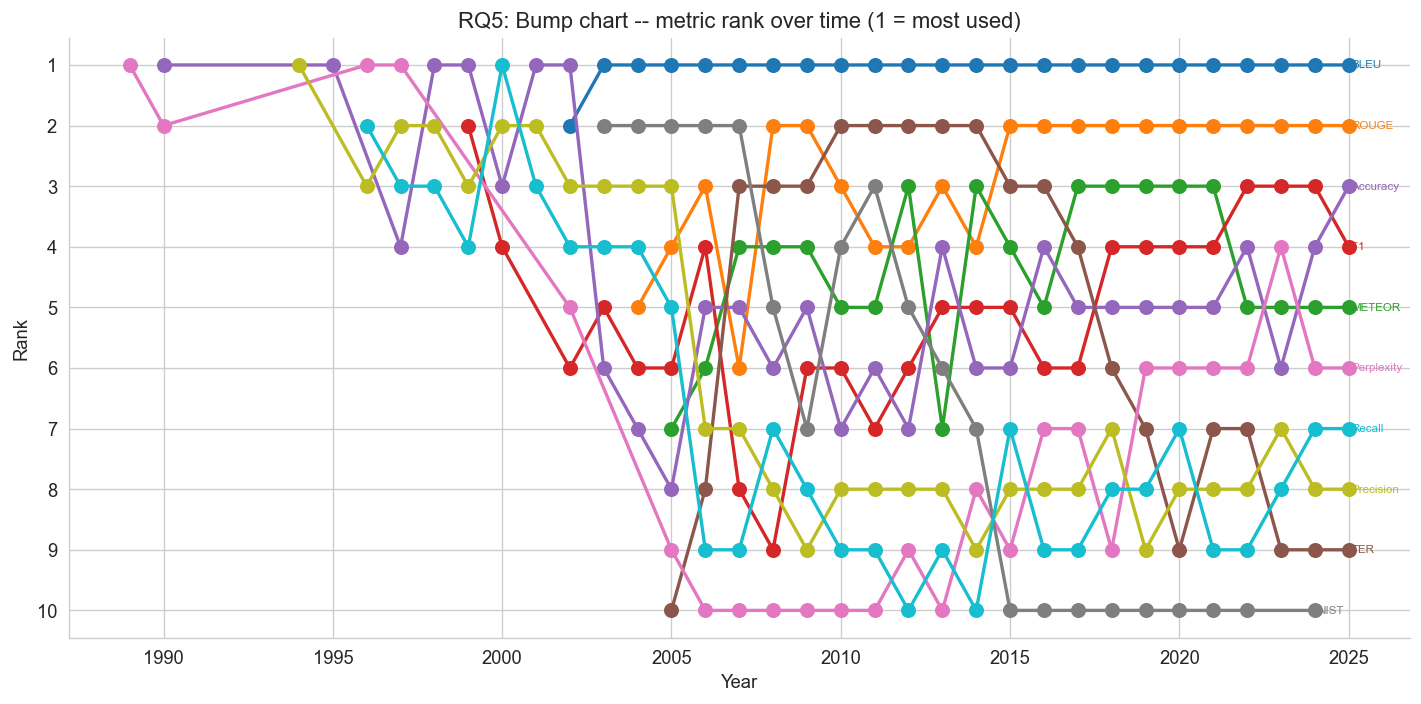

ValueError: Length of values (2) does not match length of index (5)

In [103]:
# 6.2 Bump chart: top 10 metrics over time
top10_metrics = [
    m for m in ae_exp_all.value_counts().head(12).index
    if m not in ('other', 'Other')
][:10]

rank_data = {}
for yr in sorted(ae_papers['year'].unique()):
    sub = metric_yr_exp[metric_yr_exp['year'] == yr]
    counts = sub[sub['metric'].isin(top10_metrics)]['metric'].value_counts()
    rank_data[yr] = counts.rank(ascending=False, method='first').to_dict()

rank_df = pd.DataFrame(rank_data, index=top10_metrics).T.sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
cmap10 = plt.cm.get_cmap('tab10', len(top10_metrics))
for i, metric in enumerate(top10_metrics):
    yv = rank_df[metric].dropna()
    ax.plot(yv.index, yv.values, marker='o', label=metric,
            color=cmap10(i), linewidth=2, markersize=8)
    if len(yv):
        ax.text(yv.index[-1] + 0.08, yv.iloc[-1], metric, fontsize=7,
                va='center', color=cmap10(i))

ax.invert_yaxis()
ax.set_title('RQ5: Bump chart -- metric rank over time (1 = most used)')
ax.set_xlabel('Year')
ax.set_ylabel('Rank')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
save_fig(fig, 'rq5_metric_bump')
plt.show()

# Save top-metrics-by-year table
top5_per_year = {}
for yr in sorted(ae_papers['year'].unique()):
    sub = metric_yr_exp[metric_yr_exp['year'] == yr]
    top5_per_year[yr] = sub['metric'].value_counts().head(5).index.tolist()
tbl_metrics_yr = pd.DataFrame(top5_per_year, index=[f'rank_{i+1}' for i in range(5)]).T
tbl_metrics_yr.index.name = 'year'
tbl_metrics_yr.to_csv('tables/rq5_top_metrics_by_year.csv')
print("Saved tables/rq5_top_metrics_by_year.csv")
print(tbl_metrics_yr.to_string())

In [ ]:
# 6.3 Neural vs. lexical metric ratio
LEXICAL = {'BLEU','ROUGE','METEOR','chrF','TER','NIST','CIDEr','RIBES','GTM','PER','AER','SARI','WER','Self-BLEU'}
NEURAL  = {'BERTScore','BLEURT','COMET','MoverScore','BARTScore','UniEval'}

metric_yr_exp['metric_class'] = metric_yr_exp['metric'].apply(
    lambda m: 'lexical' if m in LEXICAL else ('neural' if m in NEURAL else 'other')
)

cls_yr = (
    metric_yr_exp[metric_yr_exp['metric_class'] != 'other']
    .groupby(['year', 'metric_class']).size().unstack(fill_value=0)
)
cls_yr_pct = cls_yr.div(cls_yr.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cls_yr.plot(kind='bar', stacked=True, ax=axes[0], color=['#4C72B0', '#55A868'], alpha=0.8)
axes[0].set_title('Metric class mentions per year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

cls_yr_pct.plot(kind='area', stacked=True, ax=axes[1], color=['#4C72B0', '#55A868'], alpha=0.65)
axes[1].set_title('Metric class proportion per year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Proportion')

plt.suptitle('RQ5: Neural vs. lexical metrics')
plt.tight_layout()
save_fig(fig, 'rq5_neural_vs_lexical')
plt.show()

In [ ]:
# 6.4 Metrics by task heatmap (df_single)
ae_single = df_single[df_single['has_auto_eval'] & df_single['metrics_norm'].str.strip().astype(bool)].copy()
ae_single_exp = (
    ae_single[['task', 'metrics_norm']]
    .assign(metric=ae_single['metrics_norm'].str.split('|'))
    .explode('metric')
    .assign(metric=lambda x: x['metric'].str.strip())
)
ae_single_exp = ae_single_exp[ae_single_exp['metric'] != 'other']

ae_per_task = ae_single.groupby('task').size().rename('ae_total')
met_task = (
    ae_single_exp[ae_single_exp['metric'].isin(top10_metrics)]
    .groupby(['task', 'metric']).size()
    .reset_index(name='count')
    .merge(ae_per_task, on='task')
    .assign(rate=lambda x: x['count'] / x['ae_total'])
)
top_tsk_ae = ae_single['task'].value_counts().head(10).index
pivot_mt = (
    met_task.pivot(index='metric', columns='task', values='rate')
    .fillna(0)
    .reindex(columns=[t for t in top_tsk_ae if t in met_task['task'].unique()])
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot_mt, annot=True, fmt='.0%', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('RQ5: Metrics by task (% of single-task auto-eval papers)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
save_fig(fig, 'rq5_metrics_by_task')
plt.show()

In [ ]:
# 6.5 Metric diversity (num_metrics) over time
print("Metric count per paper by year:")
print(ae_papers.groupby('year')['num_metrics'].describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
ae_papers.boxplot(
    column='num_metrics', by='year', ax=ax,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='darkorange', linewidth=2),
    flierprops=dict(marker='.', markersize=3),
)
ax.set_title('RQ5: Metric diversity per paper by year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of distinct metrics')
plt.suptitle('')
plt.tight_layout()
save_fig(fig, 'rq5_metric_diversity')
plt.show()

In [ ]:
# 6.6 Metrics by language group
print("Metric class usage by language group:")
ae_lang = df[df['has_auto_eval'] & df['metrics_norm'].str.strip().astype(bool)
             & (df['lang_group'] != 'unknown')].copy()
ae_lang_exp = (
    ae_lang[['lang_group', 'metrics_norm']]
    .assign(metric=ae_lang['metrics_norm'].str.split('|'))
    .explode('metric')
    .assign(metric=lambda x: x['metric'].str.strip())
)
ae_lang_exp['class'] = ae_lang_exp['metric'].apply(
    lambda m: 'lexical' if m in LEXICAL else ('neural' if m in NEURAL else 'other')
)
print(ae_lang_exp.groupby(['lang_group', 'class']).size()
      .unstack(fill_value=0)
      .div(ae_lang.groupby('lang_group').size(), axis=0)
      .round(3).to_string())

---
## Section 7 -- RQ6: Task-Based Evaluation Culture Differences

In [ ]:
TOP_TASKS_RQ6 = df_single['task'].value_counts().head(8).index.tolist()

# 7.1 Human eval rate by task -- small multiples
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=False)
for ax, task in zip(axes.flatten(), TOP_TASKS_RQ6):
    sub = df_single[df_single['task'] == task]
    if len(sub) == 0:
        ax.set_title(task); continue
    dual_axis_trend(sub, 'year', 'has_human_eval', task, ax=ax)
    ax.set_xlabel('')

plt.suptitle('RQ6: Human eval rate per task over time (single-task papers)', y=1.01)
plt.tight_layout()
save_fig(fig, 'rq6_human_eval_by_task')
plt.show()

In [ ]:
# 7.2 Top 3 metrics per top-4 task over time
TOP4 = ['machine_translation', 'summarization', 'data_to_text', 'dialogue']
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
for ax, task in zip(axes, TOP4):
    task_ae = ae_single[ae_single['task'] == task]
    if len(task_ae) == 0:
        ax.set_title(task); continue
    task_exp = ae_single_exp[ae_single_exp['task'] == task]
    top3 = task_exp['metric'].value_counts().head(3).index.tolist()
    task_yr_total = task_ae.groupby('year').size().rename('total')
    for metric in top3:
        sub = (
            task_exp[task_exp['metric'] == metric]
            .groupby('year').size().reset_index(name='count')
            .merge(task_yr_total, on='year')
            .assign(rate=lambda x: x['count'] / x['total'])
        )
        ax.plot(sub['year'], sub['rate'], marker='o', label=metric, linewidth=2)
    ax.set_title(task, fontsize=9)
    ax.set_xlabel('Year')
    ax.set_ylabel('Proportion')
    ax.legend(fontsize=7)
plt.suptitle('RQ6: Top 3 metrics per task over time')
plt.tight_layout()
save_fig(fig, 'rq6_metrics_by_task')
plt.show()

In [ ]:
# 7.3 Evaluation profile summary table
def _most_common(series_pipe, exclude=('other',)):
    vals = (series_pipe.str.split('|').explode().str.strip()
            .replace('', np.nan).dropna())
    vals = vals[~vals.isin(exclude)]
    return vals.value_counts().index[0] if len(vals) > 0 else None

profiles = []
for task in TOP_TASKS_RQ6:
    sub   = df_single[df_single['task'] == task]
    he_s  = sub[sub['has_human_eval']]
    ae_s  = sub[sub['has_auto_eval']]
    profiles.append({
        'task':                   task,
        'n_papers':               len(sub),
        'pct_human_eval':         f"{sub['has_human_eval'].mean()*100:.1f}%",
        'pct_auto_eval':          f"{sub['has_auto_eval'].mean()*100:.1f}%",
        'pct_llm_judge':          f"{sub['has_llm_judge'].mean()*100:.1f}%",
        'pct_both_human_auto':    f"{(sub['has_human_eval'] & sub['has_auto_eval']).mean()*100:.1f}%",
        'median_annotators':      he_s['num_annotators'].median() if len(he_s) else None,
        'median_metric_diversity': ae_s['num_metrics'].median() if len(ae_s) else None,
        'most_common_criterion':  _most_common(he_s['criteria_norm']) if len(he_s) else None,
        'most_common_method':     _most_common(he_s['methods_norm'])  if len(he_s) else None,
    })

profiles_df = pd.DataFrame(profiles).set_index('task')
print("=== Evaluation Profile per Task ===")
print(profiles_df.to_string())
profiles_df.to_csv('tables/rq6_eval_profiles.csv')
print("\nSaved tables/rq6_eval_profiles.csv")

In [ ]:
# 7.4 Multi-task vs. single-task eval_type divergence per task
print("\nMulti-task vs. single-task: eval modality divergence")
for task in TOP_TASKS_RQ6[:6]:
    single_he = df_single[df_single['task'] == task]['has_human_eval'].mean()
    # multi-task: papers where this task is one of several
    multi_sub  = df_tasks[(df_tasks['task'] == task) & df_tasks['is_multi_task']]
    multi_he   = multi_sub['has_human_eval'].mean() if len(multi_sub) else float('nan')
    print(f"  {task:30s}: single={single_he:.1%}  multi={multi_he:.1%}  "
          f"delta={single_he - multi_he:+.1%}  (n_multi={len(multi_sub)})")

---
## Section 8 -- RQ7: Scale of Human Evaluation Over Time

In [ ]:
he_all = df[df['has_human_eval']].copy()
print(f"Human-eval papers: {len(he_all):,}")
print(f"num_annotators reported: {he_all['num_annotators'].notna().sum()} "
      f"({he_all['num_annotators'].notna().mean()*100:.1f}%)")
print(f"num_items_rated reported: {he_all['num_items_rated'].notna().sum()} "
      f"({he_all['num_items_rated'].notna().mean()*100:.1f}%)")

In [ ]:
# 8.1 Reporting rates over time
he_yr = he_all.groupby('year').size().rename('total')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in [
    (axes[0], 'num_annotators',  'num_annotators reported'),
    (axes[1], 'num_items_rated', 'num_items_rated reported'),
]:
    rep = he_all[he_all[col].notna()].groupby('year').size().rename('count')
    merged = pd.concat([he_yr, rep], axis=1).fillna(0)
    merged['rate'] = merged['count'] / merged['total']
    ax.bar(merged.index.astype(str), merged['count'], color='steelblue', alpha=0.6)
    ax2 = ax.twinx()
    ax2.plot(range(len(merged)), merged['rate'], color='darkorange', marker='o', linewidth=2)
    ax2.set_ylim(0, 1)
    ax.set_title(f'RQ7: {label}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    ax2.set_ylabel('Proportion')
plt.tight_layout()
save_fig(fig, 'rq7_reporting_rate')
plt.show()

In [ ]:
# 8.2 Annotator counts over time
he_ann = he_all[he_all['num_annotators'].notna() & (he_all['num_annotators'] > 0)].copy()
print(f"Papers with valid annotator count: {len(he_ann)}")
print(he_ann.groupby('year')['num_annotators'].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
he_ann.boxplot(
    column='num_annotators', by='year', ax=ax,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='darkorange', linewidth=2),
    flierprops=dict(marker='.', markersize=3),
    showfliers=True,
)
ax.set_title('RQ7: Annotator counts by year (WMT outliers expected)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of annotators (capped at 50 for visibility)')
ax.set_ylim(0, 50)
plt.suptitle('')
plt.tight_layout()
save_fig(fig, 'rq7_annotator_counts')
plt.show()

In [ ]:
# 8.3 Agreement reporting rate
fig, ax = plt.subplots(figsize=(10, 5))
dual_axis_trend(he_all, 'year', 'agreement_reported',
                'RQ7: Inter-annotator agreement reporting rate over time', ax=ax,
                color_bar='#55A868', color_line='#8172B2')
plt.tight_layout()
save_fig(fig, 'rq7_agreement_reporting')
plt.show()

agree_yr = he_all.groupby('year')['agreement_reported'].agg(['sum', 'count', 'mean'])
agree_yr.columns = ['reported', 'total', 'rate']
print(agree_yr.to_string())

print("\nAgreement metrics used:")
print(he_all[he_all['agreement_reported']]['agreement_metric'].value_counts().to_string())

In [ ]:
# 8.4 Missingness matrix over time
HE_FIELDS = {
    'human_eval_methods':  'methods',
    'human_eval_criteria': 'criteria',
    'num_annotators':      'num_annotators',
    'num_items_rated':     'num_items_rated',
    'agreement_metric':    'agreement_metric',
}

miss_rows = {}
for yr in sorted(he_all['year'].unique()):
    sub = he_all[he_all['year'] == yr]
    n = len(sub)
    row = {}
    for field, label in HE_FIELDS.items():
        missing = (sub[field].isna() | (sub[field].astype(str).str.strip() == '')).sum()
        row[label] = missing / n
    # agreement_reported is boolean -- "missing" means not reported
    row['agreement_reported'] = (~sub['agreement_reported']).sum() / n
    miss_rows[yr] = row

miss_df = pd.DataFrame(miss_rows).T

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(miss_df.T, annot=True, fmt='.0%', cmap='Reds',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('RQ7: Missingness in human-eval metadata over time
(red = higher missingness)')
ax.set_xlabel('Year')
ax.set_ylabel('Field')
plt.tight_layout()
save_fig(fig, 'rq7_missingness')
plt.show()
print(miss_df.round(2).to_string())

---
## Section 9 -- Summary Composite Figure

Publish-ready 4-panel figure. Iterate on colour palette before final export.

In [ ]:
fig = plt.figure(figsize=(20, 14))
gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.32)

# Panel A: Stacked area -- eval modality
ax_a = fig.add_subplot(gs[0, 0])
et_year_pct.plot(kind='area', stacked=True, ax=ax_a, color=ET4_COLORS, alpha=0.75, legend=False)
ax_a.set_title('(A) Evaluation modality over time', fontweight='bold')
ax_a.set_xlabel('Year')
ax_a.set_ylabel('Proportion')
ax_a.legend(ET4_ORDER, fontsize=7, loc='upper left')

# Panel B: Criteria category proportions
ax_b = fig.add_subplot(gs[0, 1])
pivot_grp.plot(kind='area', stacked=False, ax=ax_b, alpha=0.55, legend=False)
ax_b.set_title('(B) Human eval criteria categories over time', fontweight='bold')
ax_b.set_xlabel('Year')
ax_b.set_ylabel('Proportion of human-eval papers')
ax_b.legend(fontsize=7, loc='upper right')

# Panel C: Human eval rate per top-6 task
ax_c = fig.add_subplot(gs[1, 0])
task_yr_he = (
    df_single[df_single['task'].isin(TOP_TASKS_RQ6[:6])]
    .groupby(['task', 'year'])['has_human_eval']
    .agg(['sum', 'count'])
    .reset_index()
    .assign(rate=lambda x: x['sum'] / x['count'])
)
cmap6 = plt.cm.tab10
for i, task in enumerate(TOP_TASKS_RQ6[:6]):
    sub = task_yr_he[task_yr_he['task'] == task].sort_values('year')
    ax_c.plot(sub['year'], sub['rate'], marker='o', label=task,
              color=cmap6(i), linewidth=2)
ax_c.set_title('(C) Human eval rate by task over time', fontweight='bold')
ax_c.set_xlabel('Year')
ax_c.set_ylabel('Proportion')
ax_c.legend(fontsize=7)

# Panel D: LLM-judge adoption
ax_d = fig.add_subplot(gs[1, 1])
llm_yr = (
    df.groupby('year')['has_llm_judge']
    .agg(['sum', 'count', 'mean'])
    .reset_index()
)
llm_yr.columns = ['year', 'count', 'total', 'rate']
ax_d.bar(llm_yr['year'].astype(str), llm_yr['count'], color='#C44E52', alpha=0.7)
ax_d2 = ax_d.twinx()
ax_d2.plot(range(len(llm_yr)), llm_yr['rate'], color='darkred', marker='o', linewidth=2)
ax_d2.set_ylim(0, max(0.15, llm_yr['rate'].max() * 1.2))
ax_d.set_title('(D) LLM-as-judge adoption over time', fontweight='bold')
ax_d.set_xlabel('Year')
ax_d.set_ylabel('Count', color='#C44E52')
ax_d2.set_ylabel('Proportion', color='darkred')

plt.suptitle('NLG Evaluation Trends (2019-2025)', fontsize=16, fontweight='bold', y=1.01)
save_fig(fig, 'summary_composite')
plt.show()
print("Summary composite figure saved.")

---
## Section 10 -- Robustness Checks

In [ ]:
SUBSETS = {
    'Full dataset':             df,
    'No meta-eval':             df[~df['is_meta_eval']],
    'Heading extraction only':  df[df['extraction_method'] == 'heading_heuristic'],
    'No parse failures':        df[~df['parse_failed']],
    'INLG only':                df[df['venue'] == 'inlg'],
    'Single-task only':         df[~df['is_multi_task']],
}
if 'haiku_spot_checked' in df.columns:
    SUBSETS['Haiku-checked only'] = df[df['haiku_spot_checked']]

rows = []
for name, sub in SUBSETS.items():
    if len(sub) == 0:
        continue
    ae_s = sub[sub['has_auto_eval'] & sub['metrics_norm'].str.strip().astype(bool)]
    bleu_n = ae_s['metrics_norm'].str.contains('BLEU', na=False).sum() if len(ae_s) else 0
    rows.append({
        'subset':              name,
        'n_papers':            len(sub),
        'pct_human_eval':      f"{sub['has_human_eval'].mean()*100:.1f}%",
        'pct_auto_eval':       f"{sub['has_auto_eval'].mean()*100:.1f}%",
        'pct_bleu_among_ae':   f"{bleu_n/len(ae_s)*100:.1f}%" if len(ae_s) else 'N/A',
        'pct_llm_judge':       f"{sub['has_llm_judge'].mean()*100:.1f}%",
    })

rob_df = pd.DataFrame(rows).set_index('subset')
print("=== Robustness Check Results ===")
print(rob_df.to_string())
rob_df.to_csv('tables/robustness.csv')
print("\nSaved tables/robustness.csv")

In [ ]:
# Pipeline quality template -- fill in manually after reading 15-20 papers
pq = pd.DataFrame({
    'field':     ['has_human_eval', 'has_auto_eval', 'has_llm_judge',
                  'criteria (top 3)', 'metrics (top 3)', 'methods', 'num_annotators'],
    'precision': [None] * 7,
    'recall':    [None] * 7,
    'notes':     [''] * 7,
})
pq.to_csv('tables/pipeline_quality.csv', index=False)
print("Pipeline quality template saved to tables/pipeline_quality.csv")
print("Fill in manually after reading 15-20 diverse papers.")
print(pq.to_string(index=False))

---
## Done

All sections complete.  
Figures -> `figures/`  |  Tables -> `tables/`